In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/95a1cebd72513c794a2eb296ff5784a6_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/19e6c820c4e40f2fb5774b89bd8c7436_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/1af453efd0dbfff670205235e198dcef_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/71e8e2b61c8bc0ef25d017174026a34e_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/c5fe238d136fb833ec968c76b5e86c74_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/cd62230bc6190555b1da0ce65473cc61_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/4d5b5bdba9b46c8f470daabac4a08fb0_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/36d6aed87f01afe75b731693eee28829_Abnormal.dicom


In [2]:
!pip install -q timm transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 79.1 MB/s eta 0:00:00:00:0100:01


# Imports

In [3]:
import os
import cv2
import faiss
import torch
import timm
import numpy as np

import torch.nn as nn

from PIL import Image
from torch.utils.data import Dataset,DataLoader

from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Dataset Loader

In [4]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 224

# Correct Kaggle path
BASE_DIR = "/kaggle/input/chest/chest"

# Read all splits (train + val + test)
SPLITS = ["train", "val", "test"]

images = []
labels = []

VALID_EXT = (".png", ".jpg", ".jpeg")

for split in SPLITS:
    split_path = os.path.join(BASE_DIR, split)

    if not os.path.exists(split_path):
        print(f"Missing: {split_path}")
        continue

    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)

        if not os.path.isdir(cls_path):
            continue

        count = 0

        for file in os.listdir(cls_path):
            if file.lower().endswith(VALID_EXT):
                img_path = os.path.join(cls_path, file)

                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                images.append(img)
                labels.append(cls)
                count += 1

        print(f"{split}/{cls}: {count} images")

images = np.array(images)
labels = np.array(labels)

print("\nTotal Images:", len(images))
print("Classes:", np.unique(labels))

encoder = LabelEncoder()
y = encoder.fit_transform(labels)

Missing: /kaggle/input/chest/chest/train
Missing: /kaggle/input/chest/chest/val
Missing: /kaggle/input/chest/chest/test

Total Images: 0
Classes: []


In [5]:
import os

BASE = "/kaggle/input/chest"

print("=" * 80)
print("DATASET EXISTS:", os.path.exists(BASE))
print("BASE PATH:", BASE)
print("=" * 80)

if os.path.exists(BASE):

    for root, dirs, files in os.walk(BASE):
        level = root.replace(BASE, "").count(os.sep)
        indent = "    " * level

        print(f"{indent}{os.path.basename(root)}/")

        # Show first 10 files only
        for f in files[:10]:
            print(f"{indent}    {f}")

        if len(files) > 10:
            print(f"{indent}    ... ({len(files)} files total)")

else:
    print("Dataset path does not exist.")
    print("\nAvailable Kaggle input datasets:")

    if os.path.exists("/kaggle/input"):
        for item in os.listdir("/kaggle/input"):
            print(" ->", item)

DATASET EXISTS: False
BASE PATH: /kaggle/input/chest
Dataset path does not exist.

Available Kaggle input datasets:
 -> datasets


In [6]:
import os

BASE = "/kaggle/input/chest"

extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_files = []

for root, dirs, files in os.walk(BASE):
    for file in files:
        if file.lower().endswith(extensions):
            image_files.append(os.path.join(root, file))

print("Total images found:", len(image_files))

print("\nFirst 30 images:")
for path in image_files[:30]:
    print(path)

Total images found: 0

First 30 images:


In [7]:
import os

print("KAGGLE INPUT CONTENTS")
print("=" * 60)

for item in os.listdir("/kaggle/input"):
    path = os.path.join("/kaggle/input", item)

    if os.path.isdir(path):
        print(f"\n📁 {item}")

        for sub in os.listdir(path):
            subpath = os.path.join(path, sub)

            if os.path.isdir(subpath):
                print(f"   └── 📁 {sub}")
            else:
                print(f"   └── 📄 {sub}")
    else:
        print(f"📄 {item}")

KAGGLE INPUT CONTENTS

📁 datasets
   └── 📁 ashwinialashetty


In [8]:
import os

ROOT = "https://www.kaggle.com/datasets/ashwinialashetty/chestdoc"

for root, dirs, files in os.walk(ROOT):
    dicom_count = sum(
        f.lower().endswith(".dicom")
        for f in files
    )

    if dicom_count:
        print(root, "→", dicom_count, "DICOM files")

In [9]:
!pip install -q pydicom

In [10]:
import os

ROOT = "https://www.kaggle.com/datasets/ashwinialashetty/chestdoc"

print("Searching inside:", ROOT)

dicom_files = []

for root, dirs, files in os.walk(ROOT):
    for f in files:
        if f.lower().endswith(".dicom"):
            dicom_files.append(os.path.join(root, f))

print(f"Total DICOM files found: {len(dicom_files)}")

# show the first few paths
for p in dicom_files[:10]:
    print(p)

Searching inside: https://www.kaggle.com/datasets/ashwinialashetty/chestdoc
Total DICOM files found: 0


In [11]:
import os

ROOT = "https://www.kaggle.com/datasets/ashwinialashetty/chestdoc"

dicom_files = []

for root, dirs, files in os.walk(ROOT):
    for file in files:
        if file.lower().endswith(".dicom"):
            dicom_files.append(os.path.join(root, file))

print("Total DICOM files:", len(dicom_files))

for p in dicom_files[:20]:
    print(p)

Total DICOM files: 0


In [12]:
!kaggle datasets download -d ashwinialashetty/chestdoc -p /kaggle/working/chestdoc

Dataset URL: https://www.kaggle.com/datasets/ashwinialashetty/chestdoc
License(s): unknown
100%|███████████████████████████████████████| 6.66G/6.66G [00:54<00:00, 130MB/s]



In [13]:
import zipfile
import os

zip_file = "/kaggle/working/chestdoc/chestdoc.zip"
extract_dir = "/kaggle/working/chestdoc/data"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:")
print(extract_dir)

OSError: [Errno 28] No space left on device

In [14]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [15]:
import os

ROOT = "/kaggle/input/chestdoc"

dicom_files = []

for root, _, files in os.walk(ROOT):
    for f in files:
        if f.lower().endswith(".dicom"):
            dicom_files.append(os.path.join(root, f))

print(f"Total DICOM files: {len(dicom_files)}")
print(dicom_files[:10])

Total DICOM files: 0
[]


In [16]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    if files:
        print(root, "->", len(files), "files")

/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251 -> 962 files
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr207/intbtr207 -> 681 files


In [17]:
import os

ROOT = "/kaggle/input/datasets"

dicom_files = []

for root, _, files in os.walk(ROOT):
    for f in files:
        if f.lower().endswith(".dicom"):
            dicom_files.append(os.path.join(root, f))

print("Total DICOM files:", len(dicom_files))

for f in dicom_files[:10]:
    print(f)

Total DICOM files: 1643
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/95a1cebd72513c794a2eb296ff5784a6_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/19e6c820c4e40f2fb5774b89bd8c7436_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/1af453efd0dbfff670205235e198dcef_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/71e8e2b61c8bc0ef25d017174026a34e_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/c5fe238d136fb833ec968c76b5e86c74_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/cd62230bc6190555b1da0ce65473cc61_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/4d5b5bdba9b46c8f470daabac4a08fb0_Abnormal.dicom
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/36d6aed87f01afe75b731693

In [18]:
!pip install -q pydicom

import os
import cv2
import pydicom
import numpy as np
import pandas as pd
from tqdm import tqdm

IMG_SIZE = 224
ROOT = "/kaggle/input/datasets"

records = []

for root, _, files in os.walk(ROOT):
    for file in tqdm(files):
        if not file.lower().endswith(".dicom"):
            continue

        path = os.path.join(root, file)

        label = "Normal" if "_Normal" in file else "Abnormal"

        ds = pydicom.dcmread(path)
        img = ds.pixel_array.astype(np.float32)

        img -= img.min()
        img /= (img.max() + 1e-8)
        img = (img * 255).astype(np.uint8)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        patient = getattr(ds, "PatientID", file.split("_")[0])

        records.append({
            "image": img,
            "label": label,
            "patient": str(patient),
            "path": path
        })

df = pd.DataFrame(records)

print(df.label.value_counts())
print("Total:", len(df))

0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 962/962 [01:16<00:00, 12.55it/s]
0it [00:00, ?it/s]
100%|██████████| 681/681 [00:38<00:00, 17.79it/s]


label
Abnormal    962
Normal      681
Name: count, dtype: int64
Total: 1643


In [19]:
import os
import pandas as pd
import pydicom
from tqdm import tqdm

records = []

for path in tqdm(dicom_files):

    filename = os.path.basename(path)

    if "_Normal" in filename:
        label = "Normal"
    elif "_Abnormal" in filename:
        label = "Abnormal"
    else:
        continue

    # Use filename prefix as unique identifier
    patient = filename.split("_")[0]

    records.append({
        "path": path,
        "label": label,
        "patient": patient
    })

df = pd.DataFrame(records)

print(df.head())
print(df["label"].value_counts())
print("Unique patient/image IDs:", df["patient"].nunique())

100%|██████████| 1643/1643 [00:00<00:00, 561130.32it/s]

                                                path     label  \
0  /kaggle/input/datasets/ashwinialashetty/chestd...  Abnormal   
1  /kaggle/input/datasets/ashwinialashetty/chestd...  Abnormal   
2  /kaggle/input/datasets/ashwinialashetty/chestd...  Abnormal   
3  /kaggle/input/datasets/ashwinialashetty/chestd...  Abnormal   
4  /kaggle/input/datasets/ashwinialashetty/chestd...  Abnormal   

                            patient  
0  95a1cebd72513c794a2eb296ff5784a6  
1  19e6c820c4e40f2fb5774b89bd8c7436  
2  1af453efd0dbfff670205235e198dcef  
3  71e8e2b61c8bc0ef25d017174026a34e  
4  c5fe238d136fb833ec968c76b5e86c74  
label
Abnormal    962
Normal      681
Name: count, dtype: int64
Unique patient/image IDs: 1643


In [20]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["target"] = encoder.fit_transform(df["label"])

# 80% train, 20% temp
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(df, groups=df["patient"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# Split temp into validation and test (10% each)
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(temp_df, groups=temp_df["patient"])
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution")
print(train_df["label"].value_counts())

print("\nValidation distribution")
print(val_df["label"].value_counts())

print("\nTest distribution")
print(test_df["label"].value_counts())

Train: 1314
Validation: 164
Test: 165

Train distribution
label
Abnormal    771
Normal      543
Name: count, dtype: int64

Validation distribution
label
Abnormal    96
Normal      68
Name: count, dtype: int64

Test distribution
label
Abnormal    95
Normal      70
Name: count, dtype: int64


In [21]:
import cv2
import pydicom
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

class ChestDataset(Dataset):

    def __init__(self, dataframe, transform):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        ds = pydicom.dcmread(row.path)

        img = ds.pixel_array.astype(np.float32)

        img -= img.min()
        img /= (img.max() + 1e-8)

        img = (img * 255).astype(np.uint8)

        # CLAHE
        img = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8,8)
        ).apply(img)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        img = self.transform(img)

        return img, torch.tensor(row.target, dtype=torch.long)

In [22]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    ChestDataset(train_df, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    ChestDataset(val_df, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    ChestDataset(test_df, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 83
Validation batches: 11
Test batches: 11


# Proposed Adaptive Fusion Module (AHF)

This is the proposed contribution.

Instead of fixed concatenation:

F=F
cnn
	​

⊕F
vit
	​


we learn adaptive weights:

F=wF
cnn
	​

+(1−w)F
vit
	​


In [23]:
import torch
import torch.nn as nn

class AdaptiveFusion(nn.Module):

    def __init__(self, dim=512):

        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(dim*2, dim),
            nn.ReLU(inplace=True),
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, vit_feat):

        joint = torch.cat([cnn_feat, vit_feat], dim=1)

        weight = self.attention(joint)

        fused = weight*cnn_feat + (1-weight)*vit_feat

        return fused, weight

# AHF-Net Architecture

This combines

DenseNet121 → local pathology features

Swin Transformer → global contextual features

Adaptive Fusion → learned weighting

In [24]:
import timm

class AHFNet(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        self.cnn = timm.create_model(
            "densenet121",
            pretrained=True,
            num_classes=0
        )

        self.vit = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

        cnn_dim = self.cnn.num_features
        vit_dim = self.vit.num_features

        self.cnn_proj = nn.Linear(cnn_dim,512)
        self.vit_proj = nn.Linear(vit_dim,512)

        self.fusion = AdaptiveFusion(512)

        self.classifier = nn.Sequential(
            nn.Linear(512,256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):

        cnn_feat = self.cnn_proj(self.cnn(x))
        vit_feat = self.vit_proj(self.vit(x))

        fused, weight = self.fusion(cnn_feat, vit_feat)

        output = self.classifier(fused)

        return output, weight

# Initialize Model

In [25]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AHFNet(num_classes=2).to(device)

print(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total:,}")
print(f"Trainable Parameters: {trainable:,}")

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

cuda
Total Parameters: 36,311,036
Trainable Parameters: 36,311,036


# Loss, Optimizer, Scheduler

In [26]:
import torch.optim as optim

counts = train_df.target.value_counts().sort_index().values

weights = torch.tensor(
    counts.sum()/counts,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

print("Class weights:", weights)

Class weights: tensor([1.7043, 2.4199], device='cuda:0')


# Training and Validation Functions

In [27]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Use the newer AMP API when available
try:
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
except:
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


def train_one_epoch(model, loader, criterion, optimizer, scaler):

    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if device.type == "cuda":
            with torch.amp.autocast("cuda"):
                outputs, _ = model(images)
                loss = criterion(outputs, labels)
        else:
            outputs, _ = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(predictions.detach().cpu().numpy())
        all_probs.extend(probabilities.detach().cpu().numpy())

    loss = running_loss / len(loader)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(
        all_labels, all_preds, zero_division=0
    )
    recall = recall_score(
        all_labels, all_preds, zero_division=0
    )
    f1 = f1_score(
        all_labels, all_preds, zero_division=0
    )
    auc = roc_auc_score(all_labels, all_probs)

    return loss, accuracy, precision, recall, f1, auc


def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if device.type == "cuda":
                with torch.amp.autocast("cuda"):
                    outputs, _ = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs, _ = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()

            probabilities = torch.softmax(outputs, dim=1)[:, 1]
            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())

    loss = running_loss / len(loader)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(
        all_labels, all_preds, zero_division=0
    )
    recall = recall_score(
        all_labels, all_preds, zero_division=0
    )
    f1 = f1_score(
        all_labels, all_preds, zero_division=0
    )
    auc = roc_auc_score(all_labels, all_probs)

    return loss, accuracy, precision, recall, f1, auc

In [30]:
# ============================================================
# CELL 13A — CORRECT TRAINING FUNCTION
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in loader:

        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision
        if device.type == "cuda":
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            outputs = model(images)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [31]:
# ============================================================
# CELL 13B — CORRECT VALIDATION FUNCTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, targets)

            probabilities = torch.softmax(outputs, dim=1)

            predictions = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

            # Probability of class 1 = Abnormal
            y_prob.extend(
                probabilities[:, 1].cpu().numpy()
            )

    total = len(y_true)

    epoch_loss = running_loss / total

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1,
        auc
    )

In [33]:
# ============================================================
# CELL 13A — CORRECT TRAINING FUNCTION FOR AHF-NET
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in loader:

        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ==========================================
        # FORWARD PASS
        # ==========================================
        if device.type == "cuda":

            with torch.amp.autocast("cuda"):

                output = model(images)

                # AHF-Net may return:
                # (logits, fusion_weights)
                if isinstance(output, tuple):
                    outputs = output[0]
                else:
                    outputs = output

                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:

            output = model(images)

            if isinstance(output, tuple):
                outputs = output[0]
            else:
                outputs = output

            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

        # ==========================================
        # METRICS
        # ==========================================

        running_loss += loss.item() * images.size(0)

        predicted = torch.argmax(outputs, dim=1)

        total += targets.size(0)

        correct += (
            predicted == targets
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [34]:
# ============================================================
# CELL 13B — CORRECT VALIDATION FUNCTION FOR AHF-NET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            # ==========================================
            # FORWARD PASS
            # ==========================================

            output = model(images)

            if isinstance(output, tuple):
                outputs = output[0]
            else:
                outputs = output

            loss = criterion(outputs, targets)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            y_true.extend(
                targets.cpu().numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

            # Class 1 = Abnormal
            y_prob.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
            )

    total = len(y_true)

    epoch_loss = running_loss / total

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    if len(np.unique(y_true)) > 1:

        auc = roc_auc_score(
            y_true,
            y_prob
        )

    else:

        auc = np.nan

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1,
        auc
    )

In [36]:
# ============================================================
# FIXED CHEST DATASET
# ============================================================

class ChestDataset(torch.utils.data.Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # -------------------------
        # Read DICOM
        # -------------------------
        ds = pydicom.dcmread(row["path"])

        img = ds.pixel_array.astype(np.float32)

        # -------------------------
        # Normalize
        # -------------------------
        img -= img.min()

        max_value = img.max()

        if max_value > 0:
            img /= max_value

        img = (img * 255).clip(0, 255).astype(np.uint8)

        # -------------------------
        # CLAHE
        # -------------------------
        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

        img = clahe.apply(img)

        # -------------------------
        # Resize
        # -------------------------
        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        # -------------------------
        # Convert grayscale → RGB
        # -------------------------
        img = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        # -------------------------
        # Transform
        # -------------------------
        if self.transform is not None:

            img = self.transform(img)

        else:

            # Safety conversion
            img = torch.from_numpy(img)

            img = img.permute(2, 0, 1).float() / 255.0

        # -------------------------
        # Ensure Tensor
        # -------------------------
        if not torch.is_tensor(img):
            img = torch.from_numpy(img)

        img = img.float()

        # -------------------------
        # Label
        # -------------------------
        target = torch.tensor(
            int(row["target"]),
            dtype=torch.long
        )

        return img, target

In [37]:
# ============================================================
# TRANSFORMS
# ============================================================

from torchvision import transforms

train_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=5
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
# ============================================================
# RECREATE DATASETS
# ============================================================

train_dataset = ChestDataset(
    train_df,
    transform=train_transform
)

val_dataset = ChestDataset(
    val_df,
    transform=val_transform
)

test_dataset = ChestDataset(
    test_df,
    transform=val_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1314
Validation: 164
Test: 165


In [39]:
# ============================================================
# RECREATE DATALOADERS
# ============================================================

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders recreated successfully.")

DataLoaders recreated successfully.


In [40]:
# ============================================================
# DATA TYPE TEST
# ============================================================

images, targets = next(iter(train_loader))

print("Images type :", type(images))
print("Images shape:", images.shape)
print("Images dtype:", images.dtype)

print("Targets type :", type(targets))
print("Targets shape:", targets.shape)
print("Targets dtype:", targets.dtype)

Images type : <class 'torch.Tensor'>
Images shape: torch.Size([16, 3, 224, 224])
Images dtype: torch.float32
Targets type : <class 'torch.Tensor'>
Targets shape: torch.Size([16])
Targets dtype: torch.int64


In [41]:
# ============================================================
# AHF-NET FORWARD TEST
# ============================================================

model.eval()

images, targets = next(iter(train_loader))

images = images.to(device)
targets = targets.to(device)

with torch.no_grad():

    output = model(images)

print("Output type:", type(output))

if isinstance(output, tuple):

    print("Number of outputs:", len(output))

    for i, item in enumerate(output):

        print(
            f"Output {i}: "
            f"type={type(item)}, "
            f"shape={item.shape}"
        )

else:

    print("Output shape:", output.shape)

print("Target shape:", targets.shape)

Output type: <class 'tuple'>
Number of outputs: 2
Output 0: type=<class 'torch.Tensor'>, shape=torch.Size([16, 2])
Output 1: type=<class 'torch.Tensor'>, shape=torch.Size([16, 512])
Target shape: torch.Size([16])


In [43]:
# ============================================================
# CELL 14 — TRAIN AHF-NET
# ============================================================

import os
import shutil
import numpy as np
import pandas as pd
import torch

EPOCHS = 20
PATIENCE = 5

BEST_MODEL_PATH = "/kaggle/working/best_AHFNet.pth"
TEMP_MODEL_PATH = "/kaggle/working/best_AHFNet_tmp.pth"

best_val_auc = -np.inf
patience_counter = 0

history = []

print("========================================")
print("Starting AHF-Net Training")
print("========================================")
print(f"Device: {device}")

total, used, free = shutil.disk_usage("/kaggle/working")

print(f"Free disk space: {free / (1024**3):.2f} GB")
print()

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1,
        val_auc
    ) = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # STORE HISTORY
    # ========================================================

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "val_auc": val_auc,
        "lr": current_lr
    })

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if np.isfinite(val_auc) and val_auc > best_val_auc:

        best_val_auc = val_auc
        patience_counter = 0

        if os.path.exists(TEMP_MODEL_PATH):
            os.remove(TEMP_MODEL_PATH)

        # Save only model weights
        torch.save(
            model.state_dict(),
            TEMP_MODEL_PATH
        )

        # Safely replace old checkpoint
        os.replace(
            TEMP_MODEL_PATH,
            BEST_MODEL_PATH
        )

        print(
            f"   ✓ Best model saved "
            f"(AUC = {best_val_auc:.4f})"
        )

    else:

        patience_counter += 1

        print(
            f"   No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

history_df = pd.DataFrame(history)

print()
print("========================================")
print("TRAINING COMPLETED")
print("========================================")
print(f"Best Validation AUC: {best_val_auc:.4f}")
print(f"Model saved to: {BEST_MODEL_PATH}")

if os.path.exists(BEST_MODEL_PATH):

    size_mb = (
        os.path.getsize(BEST_MODEL_PATH)
        / (1024**2)
    )

    print(f"Checkpoint size: {size_mb:.2f} MB")

Starting AHF-Net Training
Device: cuda
Free disk space: 0.00 GB

Epoch [01/20] | Train Loss: 0.0267 | Train Acc: 0.9886 | Val Loss: 0.0415 | Val Acc: 0.9878 | Val F1: 0.9855 | Val AUC: 1.0000


RuntimeError: [enforce fail at inline_container.cc:668] . unexpected pos 64 vs 0

In [44]:
# ============================================================
# FIND LARGE FILES IN /kaggle/working
# ============================================================

import os

files_found = []

for root, dirs, files in os.walk("/kaggle/working"):

    for f in files:

        path = os.path.join(root, f)

        try:
            size = os.path.getsize(path)

            files_found.append(
                (size, path)
            )

        except:
            pass


files_found.sort(reverse=True)

print("Largest files:")
print()

for size, path in files_found[:30]:

    print(
        f"{size / (1024**2):10.2f} MB   {path}"
    )

Largest files:

   6816.82 MB   /kaggle/working/chestdoc/chestdoc.zip
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/469ed6f57fe09880c2a51b6a6c496fdd_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/01ad8fc745372e1ed4427b87dc325dea_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/f6f4b4b69418810a1030fb880e705956_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/f1079478c59a7340396338ab7775f863_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/e78e415c03182e44212884b66608a332_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/d9478e922598ee3159b1560b9bbe541b_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/d5e9270d8af9d537ed067160ea0abd08_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/c6

In [45]:
# ============================================================
# FIND LARGE FILES IN /kaggle/working
# ============================================================

import os

files_found = []

for root, dirs, files in os.walk("/kaggle/working"):

    for f in files:

        path = os.path.join(root, f)

        try:
            size = os.path.getsize(path)

            files_found.append(
                (size, path)
            )

        except:
            pass


files_found.sort(reverse=True)

print("Largest files:")
print()

for size, path in files_found[:30]:

    print(
        f"{size / (1024**2):10.2f} MB   {path}"
    )

Largest files:

   6816.82 MB   /kaggle/working/chestdoc/chestdoc.zip
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/469ed6f57fe09880c2a51b6a6c496fdd_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/01ad8fc745372e1ed4427b87dc325dea_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/f6f4b4b69418810a1030fb880e705956_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/f1079478c59a7340396338ab7775f863_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/e78e415c03182e44212884b66608a332_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/d9478e922598ee3159b1560b9bbe541b_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/d5e9270d8af9d537ed067160ea0abd08_Abnormal.dicom
      9.38 MB   /kaggle/working/chestdoc/data/PostDoc/intbtr251/intbtr251/c6

In [46]:
# ============================================================
# DATASET SANITY CHECK
# ============================================================

print("TRAIN")
print(train_df["target"].value_counts())
print()

print("VALIDATION")
print(val_df["target"].value_counts())
print()

print("TEST")
print(test_df["target"].value_counts())
print()

print("Total images:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))
print()

# Check filename patterns
print("Example filenames:")
print(train_df["path"].head(10).tolist())

TRAIN
target
0    771
1    543
Name: count, dtype: int64

VALIDATION
target
0    96
1    68
Name: count, dtype: int64

TEST
target
0    95
1    70
Name: count, dtype: int64

Total images:
Train: 1314
Val  : 164
Test : 165

Example filenames:
['/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/95a1cebd72513c794a2eb296ff5784a6_Abnormal.dicom', '/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/19e6c820c4e40f2fb5774b89bd8c7436_Abnormal.dicom', '/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/1af453efd0dbfff670205235e198dcef_Abnormal.dicom', '/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/71e8e2b61c8bc0ef25d017174026a34e_Abnormal.dicom', '/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/c5fe238d136fb833ec968c76b5e86c74_Abnormal.dicom', '/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/4d5b5bdba9b46c8f470daabac4a08fb0_Abnorm

In [47]:
# ============================================================
# CHECK SOURCE DIRECTORIES
# ============================================================

from collections import Counter
import os

def source_directory_counts(dataframe):

    folders = []

    for p in dataframe["path"]:

        folders.append(
            os.path.dirname(p)
        )

    return Counter(folders)


print("TRAIN SOURCE DIRECTORIES:")
for folder, count in source_directory_counts(train_df).items():
    print(count, folder)

print()
print("VALIDATION SOURCE DIRECTORIES:")
for folder, count in source_directory_counts(val_df).items():
    print(count, folder)

print()
print("TEST SOURCE DIRECTORIES:")
for folder, count in source_directory_counts(test_df).items():
    print(count, folder)

TRAIN SOURCE DIRECTORIES:
771 /kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251
543 /kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr207/intbtr207

VALIDATION SOURCE DIRECTORIES:
96 /kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251
68 /kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr207/intbtr207

TEST SOURCE DIRECTORIES:
95 /kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251
70 /kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr207/intbtr207


In [48]:
# ============================================================
# DATASET SOURCE / IMAGE PROPERTY ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import pydicom

def inspect_dicom_properties(dataframe, n=100):

    records = []

    sample_df = dataframe.sample(
        min(n, len(dataframe)),
        random_state=42
    )

    for _, row in sample_df.iterrows():

        try:

            ds = pydicom.dcmread(
                row["path"],
                stop_before_pixels=False
            )

            img = ds.pixel_array

            records.append({

                "label": row["label"],

                "target": int(row["target"]),

                "rows": getattr(ds, "Rows", None),

                "columns": getattr(ds, "Columns", None),

                "bits_allocated":
                    getattr(ds, "BitsAllocated", None),

                "bits_stored":
                    getattr(ds, "BitsStored", None),

                "photometric":
                    getattr(ds, "PhotometricInterpretation", None),

                "samples_per_pixel":
                    getattr(ds, "SamplesPerPixel", None),

                "pixel_min":
                    float(np.min(img)),

                "pixel_max":
                    float(np.max(img)),

                "pixel_mean":
                    float(np.mean(img)),

                "pixel_std":
                    float(np.std(img))
            })

        except Exception as e:

            print(
                "Error:",
                os.path.basename(row["path"]),
                e
            )

    return pd.DataFrame(records)


# Combine the splits only for dataset-property analysis
analysis_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

property_df = inspect_dicom_properties(
    analysis_df,
    n=300
)

print("Samples inspected:", len(property_df))

print("\nImage dimensions:")
print(
    property_df
    .groupby("label")[["rows", "columns"]]
    .agg(["count", "nunique"])
)

print("\nBit depth:")
print(
    property_df
    .groupby("label")["bits_allocated"]
    .value_counts()
)

print("\nPhotometric interpretation:")
print(
    property_df
    .groupby("label")["photometric"]
    .value_counts()
)

print("\nPixel statistics:")
print(
    property_df
    .groupby("label")[
        [
            "pixel_min",
            "pixel_max",
            "pixel_mean",
            "pixel_std"
        ]
    ].mean()
)

Samples inspected: 300

Image dimensions:
          rows         columns        
         count nunique   count nunique
label                                 
Abnormal   185      15     185      13
Normal     115      83     115      90

Bit depth:
label     bits_allocated
Abnormal  16                185
Normal    16                115
Name: count, dtype: int64

Photometric interpretation:
label     photometric
Abnormal  MONOCHROME1    164
          MONOCHROME2     21
Normal    MONOCHROME1    115
Name: count, dtype: int64

Pixel statistics:
          pixel_min    pixel_max   pixel_mean    pixel_std
label                                                     
Abnormal  53.378378  4094.610811  2103.283338  1266.464845
Normal    15.356522  4095.000000  2239.714072  1187.515516


In [49]:
# ============================================================
# EXACT IMAGE SHAPE DISTRIBUTION
# ============================================================

print("Normal image shapes:")
print(
    property_df[
        property_df["target"] == 0
    ][["rows", "columns"]]
    .value_counts()
)

print("\nAbnormal image shapes:")
print(
    property_df[
        property_df["target"] == 1
    ][["rows", "columns"]]
    .value_counts()
)

Normal image shapes:
rows  columns
1994  2430       108
2010  2446        57
1572  2010         6
1568  1994         2
1507  1973         1
1622  1890         1
1495  1953         1
1486  1795         1
1671  1973         1
1633  1835         1
1757  1872         1
1772  1815         1
1803  2100         1
1795  1809         1
2010  2010         1
2446  2010         1
Name: count, dtype: int64

Abnormal image shapes:
rows  columns
2010  2446       11
1839  1872        2
1277  2043        1
1445  1883        1
1487  2045        1
                 ..
1982  1996        1
2031  1893        1
2120  1882        1
2179  2125        1
2446  2010        1
Name: count, Length: 104, dtype: int64


In [50]:
# ============================================================
# DICOM ACQUISITION INFORMATION
# ============================================================

def get_metadata_summary(dataframe, n=300):

    records = []

    sample_df = dataframe.sample(
        min(n, len(dataframe)),
        random_state=123
    )

    for _, row in sample_df.iterrows():

        try:

            ds = pydicom.dcmread(
                row["path"],
                stop_before_pixels=True
            )

            records.append({

                "label": row["label"],

                "modality":
                    getattr(ds, "Modality", "NA"),

                "manufacturer":
                    getattr(ds, "Manufacturer", "NA"),

                "model":
                    getattr(ds, "ManufacturerModelName", "NA"),

                "body_part":
                    getattr(ds, "BodyPartExamined", "NA"),

                "study_description":
                    getattr(ds, "StudyDescription", "NA"),

                "series_description":
                    getattr(ds, "SeriesDescription", "NA"),

                "photometric":
                    getattr(ds, "PhotometricInterpretation", "NA"),

                "rows":
                    getattr(ds, "Rows", "NA"),

                "columns":
                    getattr(ds, "Columns", "NA")
            })

        except:
            pass

    return pd.DataFrame(records)


metadata_df = get_metadata_summary(
    analysis_df
)

print("Metadata samples:", len(metadata_df))

for column in [
    "modality",
    "manufacturer",
    "model",
    "body_part",
    "photometric",
    "rows",
    "columns"
]:

    print("\n================================")
    print(column)
    print("================================")

    print(
        metadata_df
        .groupby("label")[column]
        .value_counts()
        .head(20)
    )

Metadata samples: 300

modality
label     modality
Abnormal  DX          115
          CR           58
Normal    CR          127
Name: count, dtype: int64

manufacturer
label     manufacturer  
Abnormal  KONICA MINOLTA    173
Normal    KONICA MINOLTA    127
Name: count, dtype: int64

model
label     model
Abnormal  0013     173
Normal    0013     127
Name: count, dtype: int64

body_part
label     body_part
Abnormal               173
Normal                 127
Name: count, dtype: int64

photometric
label     photometric
Abnormal  MONOCHROME1    145
          MONOCHROME2     28
Normal    MONOCHROME1    127
Name: count, dtype: int64

rows
label     rows
Abnormal  1994    107
          2010     44
          1572     12
          1568      2
          2446      2
          1466      1
          1604      1
          1653      1
          1803      1
          1826      1
          1832      1
Normal    2010     19
          1565      2
          1611      2
          1666      2
          1

In [51]:
# ============================================================
# IMPROVED DICOM PREPROCESSING
# ============================================================

from pydicom.pixel_data_handlers.util import apply_voi_lut

def preprocess_dicom(path, img_size=224):

    ds = pydicom.dcmread(path)

    # --------------------------------------------------------
    # Read pixel data with VOI LUT when available
    # --------------------------------------------------------

    img = apply_voi_lut(
        ds.pixel_array,
        ds
    ).astype(np.float32)

    # --------------------------------------------------------
    # Handle MONOCHROME1
    # MONOCHROME1: minimum pixel value is displayed as white
    # --------------------------------------------------------

    photometric = getattr(
        ds,
        "PhotometricInterpretation",
        ""
    )

    if photometric == "MONOCHROME1":

        img = img.max() - img

    # --------------------------------------------------------
    # Robust percentile normalization
    # --------------------------------------------------------

    low = np.percentile(img, 1)
    high = np.percentile(img, 99)

    if high > low:

        img = np.clip(
            img,
            low,
            high
        )

        img = (
            (img - low)
            / (high - low)
        )

    else:

        img = np.zeros_like(img)

    # --------------------------------------------------------
    # Convert to uint8
    # --------------------------------------------------------

    img = (
        img * 255
    ).clip(
        0,
        255
    ).astype(np.uint8)

    # --------------------------------------------------------
    # CLAHE
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    img = clahe.apply(img)

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    img = cv2.resize(
        img,
        (img_size, img_size),
        interpolation=cv2.INTER_AREA
    )

    # --------------------------------------------------------
    # Grayscale → RGB
    # --------------------------------------------------------

    img = cv2.cvtColor(
        img,
        cv2.COLOR_GRAY2RGB
    )

    return img

In [52]:
# ============================================================
# UPDATED CHEST DATASET
# ============================================================

class ChestDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # DICOM preprocessing
        img = preprocess_dicom(
            row["path"],
            IMG_SIZE
        )

        # Transform
        if self.transform is not None:

            img = self.transform(img)

        else:

            img = torch.from_numpy(
                img
            )

            img = img.permute(
                2, 0, 1
            ).float() / 255.0

        # Safety check
        if not torch.is_tensor(img):

            img = torch.from_numpy(img)

        img = img.float()

        target = torch.tensor(
            int(row["target"]),
            dtype=torch.long
        )

        return img, target

In [53]:
# ============================================================
# RECREATE DATASETS AND DATALOADERS
# ============================================================

train_dataset = ChestDataset(
    train_df,
    transform=train_transform
)

val_dataset = ChestDataset(
    val_df,
    transform=val_transform
)

test_dataset = ChestDataset(
    test_df,
    transform=val_transform
)


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Datasets and DataLoaders recreated.")

Datasets and DataLoaders recreated.


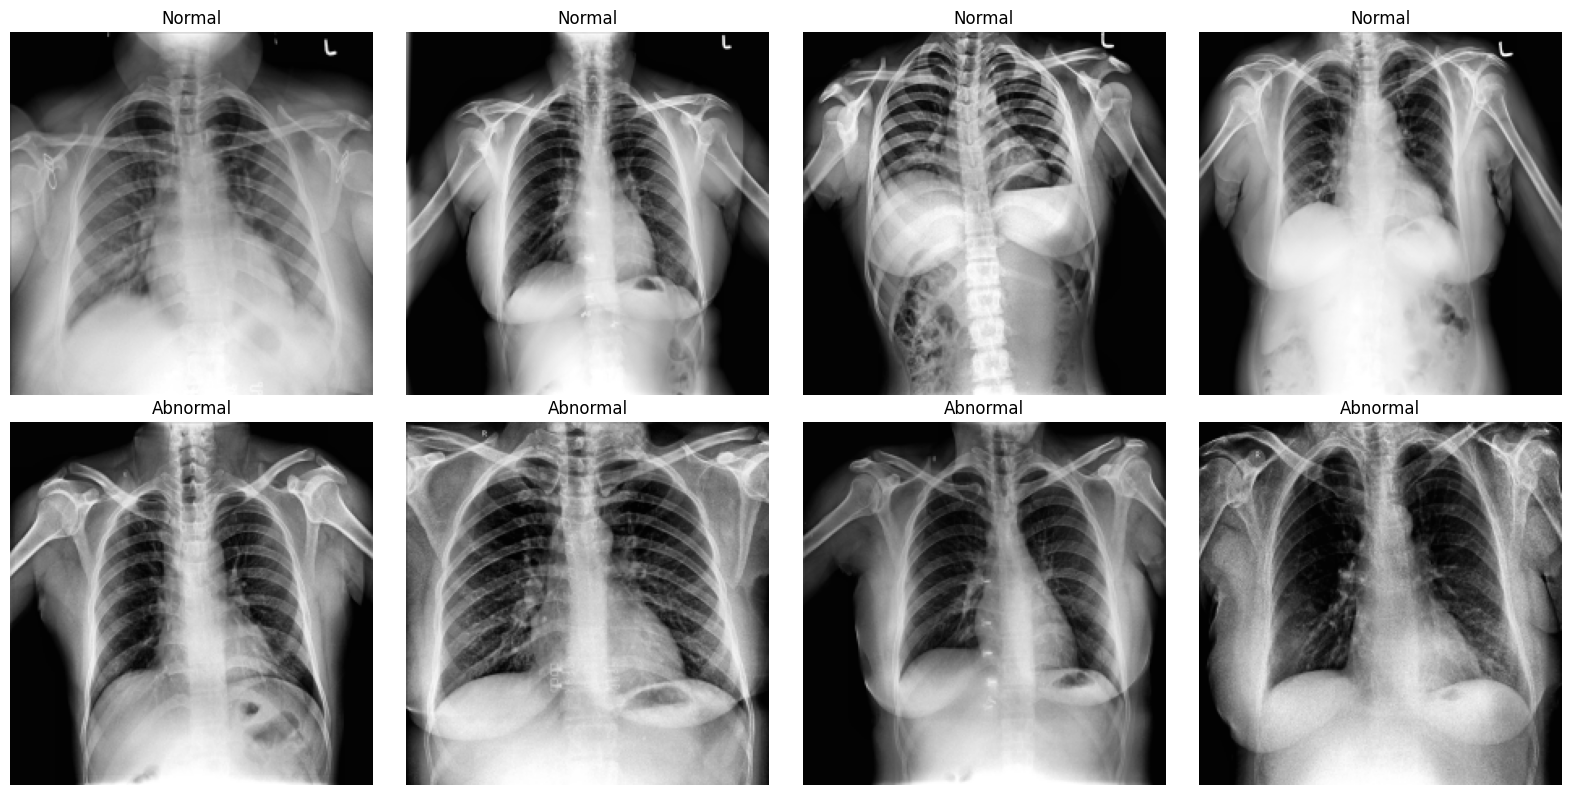

In [54]:
# ============================================================
# VISUAL DATASET CHECK
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

normal_samples = train_df[
    train_df["target"] == 0
].sample(4, random_state=42)

abnormal_samples = train_df[
    train_df["target"] == 1
].sample(4, random_state=42)


for i, (_, row) in enumerate(
    normal_samples.iterrows()
):

    img = preprocess_dicom(
        row["path"],
        IMG_SIZE
    )

    axes[0, i].imshow(
        img,
        cmap="gray"
    )

    axes[0, i].set_title(
        "Normal"
    )

    axes[0, i].axis("off")


for i, (_, row) in enumerate(
    abnormal_samples.iterrows()
):

    img = preprocess_dicom(
        row["path"],
        IMG_SIZE
    )

    axes[1, i].imshow(
        img,
        cmap="gray"
    )

    axes[1, i].set_title(
        "Abnormal"
    )

    axes[1, i].axis("off")


plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# FULL DATASET MODALITY DISTRIBUTION
# ============================================================

def get_modality_counts(dataframe):

    records = []

    for _, row in dataframe.iterrows():

        try:

            ds = pydicom.dcmread(
                row["path"],
                stop_before_pixels=True
            )

            records.append({
                "target": int(row["target"]),
                "label": row["label"],
                "modality": getattr(
                    ds,
                    "Modality",
                    "UNKNOWN"
                )
            })

        except Exception as e:

            records.append({
                "target": int(row["target"]),
                "label": row["label"],
                "modality": "ERROR"
            })

    return pd.DataFrame(records)


full_modality_df = get_modality_counts(
    analysis_df
)

print(
    pd.crosstab(
        full_modality_df["label"],
        full_modality_df["modality"]
    )
)

modality   CR   DX
label             
Abnormal  381  581
Normal    681    0


In [56]:
# ============================================================
# STEP 1: BUILD CR-ONLY DATASET
# ============================================================

import os
import pandas as pd
import pydicom
from tqdm.auto import tqdm

# Use the existing analysis_df created earlier
print("Original dataset:", len(analysis_df))

cr_records = []

for _, row in tqdm(
    analysis_df.iterrows(),
    total=len(analysis_df),
    desc="Checking DICOM modality"
):
    try:
        ds = pydicom.dcmread(row["path"], stop_before_pixels=True)
        modality = str(getattr(ds, "Modality", "UNKNOWN")).upper()

        if modality == "CR":
            cr_records.append({
                "path": row["path"],
                "label": row["label"],
                "target": int(row["target"]),
                "modality": modality
            })

    except Exception as e:
        pass

cr_df = pd.DataFrame(cr_records)

print("\n" + "="*50)
print("CR-ONLY DATASET")
print("="*50)

print("Total CR images:", len(cr_df))

print("\nClass distribution:")
print(cr_df["label"].value_counts())

print("\nClass × modality:")
print(pd.crosstab(cr_df["label"], cr_df["modality"]))

print("\nTarget distribution:")
print(cr_df["target"].value_counts().sort_index())

Original dataset: 1643


Checking DICOM modality:   0%|          | 0/1643 [00:00<?, ?it/s]


CR-ONLY DATASET
Total CR images: 1062

Class distribution:
label
Normal      681
Abnormal    381
Name: count, dtype: int64

Class × modality:
modality   CR
label        
Abnormal  381
Normal    681

Target distribution:
target
0    381
1    681
Name: count, dtype: int64


In [57]:
# ============================================================
# STEP 2: STRATIFIED CR-ONLY TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. First split: 80% train, 20% temporary
# ------------------------------------------------------------
train_df, temp_df = train_test_split(
    cr_df,
    test_size=0.20,
    stratify=cr_df["target"],
    random_state=42
)

# ------------------------------------------------------------
# 2. Split temporary set equally:
#    10% validation + 10% test
# ------------------------------------------------------------
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["target"],
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 3. Print dataset sizes
# ------------------------------------------------------------
print("=" * 60)
print("CR-ONLY DATASET SPLIT")
print("=" * 60)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")
print(f"Total      : {len(train_df) + len(val_df) + len(test_df)}")

# ------------------------------------------------------------
# 4. Class distribution
# ------------------------------------------------------------
print("\nTRAIN DISTRIBUTION")
print(train_df["label"].value_counts())

print("\nVALIDATION DISTRIBUTION")
print(val_df["label"].value_counts())

print("\nTEST DISTRIBUTION")
print(test_df["label"].value_counts())

# ------------------------------------------------------------
# 5. Target distribution
# ------------------------------------------------------------
print("\nTARGET DISTRIBUTION")

print("\nTrain:")
print(train_df["target"].value_counts().sort_index())

print("\nValidation:")
print(val_df["target"].value_counts().sort_index())

print("\nTest:")
print(test_df["target"].value_counts().sort_index())

# ------------------------------------------------------------
# 6. Verify modality
# ------------------------------------------------------------
print("\nMODALITY CHECK")

print("Train:")
print(train_df["modality"].value_counts())

print("\nValidation:")
print(val_df["modality"].value_counts())

print("\nTest:")
print(test_df["modality"].value_counts())

# ------------------------------------------------------------
# 7. Check for overlapping file paths
# ------------------------------------------------------------
train_paths = set(train_df["path"])
val_paths   = set(val_df["path"])
test_paths  = set(test_df["path"])

print("\nOVERLAP CHECK")

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test      :", len(train_paths & test_paths))
print("Validation ∩ Test :", len(val_paths & test_paths))

CR-ONLY DATASET SPLIT
Train      : 849
Validation : 106
Test       : 107
Total      : 1062

TRAIN DISTRIBUTION
label
Normal      544
Abnormal    305
Name: count, dtype: int64

VALIDATION DISTRIBUTION
label
Normal      68
Abnormal    38
Name: count, dtype: int64

TEST DISTRIBUTION
label
Normal      69
Abnormal    38
Name: count, dtype: int64

TARGET DISTRIBUTION

Train:
target
0    305
1    544
Name: count, dtype: int64

Validation:
target
0    38
1    68
Name: count, dtype: int64

Test:
target
0    38
1    69
Name: count, dtype: int64

MODALITY CHECK
Train:
modality
CR    849
Name: count, dtype: int64

Validation:
modality
CR    106
Name: count, dtype: int64

Test:
modality
CR    107
Name: count, dtype: int64

OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0


In [58]:
# ============================================================
# STEP 3: IMPROVED DICOM PREPROCESSING
# ============================================================

import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pydicom

from pydicom.pixel_data_handlers.util import apply_voi_lut


# ------------------------------------------------------------
# DICOM preprocessing function
# ------------------------------------------------------------

def preprocess_dicom(path, img_size=224):

    ds = pydicom.dcmread(path)

    # Read pixel data
    img = ds.pixel_array

    # Apply VOI LUT when available
    try:
        img = apply_voi_lut(img, ds)
    except Exception:
        pass

    img = img.astype(np.float32)

    # --------------------------------------------------------
    # Handle MONOCHROME1
    # MONOCHROME1: lower values are brighter
    # Convert to MONOCHROME2-style orientation
    # --------------------------------------------------------
    photometric = str(
        getattr(ds, "PhotometricInterpretation", "")
    ).upper()

    if photometric == "MONOCHROME1":
        img = img.max() - img

    # --------------------------------------------------------
    # Robust intensity normalization
    # --------------------------------------------------------
    low = np.percentile(img, 1)
    high = np.percentile(img, 99)

    if high > low:
        img = np.clip(img, low, high)
        img = (img - low) / (high - low)
    else:
        img = np.zeros_like(img)

    # Convert to 8-bit
    img = (img * 255.0).clip(0, 255).astype(np.uint8)

    # --------------------------------------------------------
    # CLAHE
    # --------------------------------------------------------
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    img = clahe.apply(img)

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------
    img = cv2.resize(
        img,
        (img_size, img_size),
        interpolation=cv2.INTER_AREA
    )

    # --------------------------------------------------------
    # Grayscale → RGB
    # --------------------------------------------------------
    img = cv2.cvtColor(
        img,
        cv2.COLOR_GRAY2RGB
    )

    return img


# ============================================================
# Test preprocessing on one image
# ============================================================

sample_path = train_df.iloc[0]["path"]

sample_img = preprocess_dicom(
    sample_path,
    img_size=224
)

print("Sample path:")
print(sample_path)

print("\nPreprocessed image:")
print("Shape :", sample_img.shape)
print("Dtype :", sample_img.dtype)
print("Min   :", sample_img.min())
print("Max   :", sample_img.max())

Sample path:
/kaggle/input/datasets/ashwinialashetty/chestdoc/PostDoc/intbtr251/intbtr251/be61c0772659e1defdbffde5edc24296_Abnormal.dicom

Preprocessed image:
Shape : (224, 224, 3)
Dtype : uint8
Min   : 2
Max   : 255


In [59]:
# ============================================================
# STEP 4: DATASET + DATALOADERS
# ============================================================

class ChestDICOMDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = preprocess_dicom(
            row["path"],
            img_size=224
        )

        label = int(row["target"])

        # Convert NumPy → PIL
        from PIL import Image

        image = Image.fromarray(image)

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# ImageNet normalization
# ------------------------------------------------------------

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)


# ------------------------------------------------------------
# Training augmentation
# ------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    normalize
])


# ------------------------------------------------------------
# Validation / test
# ------------------------------------------------------------

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize
])


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = ChestDICOMDataset(
    train_df,
    transform=train_transform
)

val_dataset = ChestDICOMDataset(
    val_df,
    transform=eval_transform
)

test_dataset = ChestDICOMDataset(
    test_df,
    transform=eval_transform
)


# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("=" * 60)
print("DATALOADERS CREATED")
print("=" * 60)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

DATALOADERS CREATED
Train batches: 54
Val batches  : 7
Test batches : 7


In [60]:
# ============================================================
# STEP 5: DATALOADER SANITY CHECK
# ============================================================

images, targets = next(iter(train_loader))

print("=" * 60)
print("BATCH SANITY CHECK")
print("=" * 60)

print("Images:")
print("  Type  :", type(images))
print("  Shape :", images.shape)
print("  Dtype :", images.dtype)

print("\nTargets:")
print("  Type  :", type(targets))
print("  Shape :", targets.shape)
print("  Dtype :", targets.dtype)

print("\nTarget values:")
print(torch.unique(targets))

print("\nImage range:")
print("Min:", images.min().item())
print("Max:", images.max().item())

BATCH SANITY CHECK
Images:
  Type  : <class 'torch.Tensor'>
  Shape : torch.Size([16, 3, 224, 224])
  Dtype : torch.float32

Targets:
  Type  : <class 'torch.Tensor'>
  Shape : torch.Size([16])
  Dtype : torch.int64

Target values:
tensor([0, 1])

Image range:
Min: -2.1179039478302
Max: 2.640000104904175


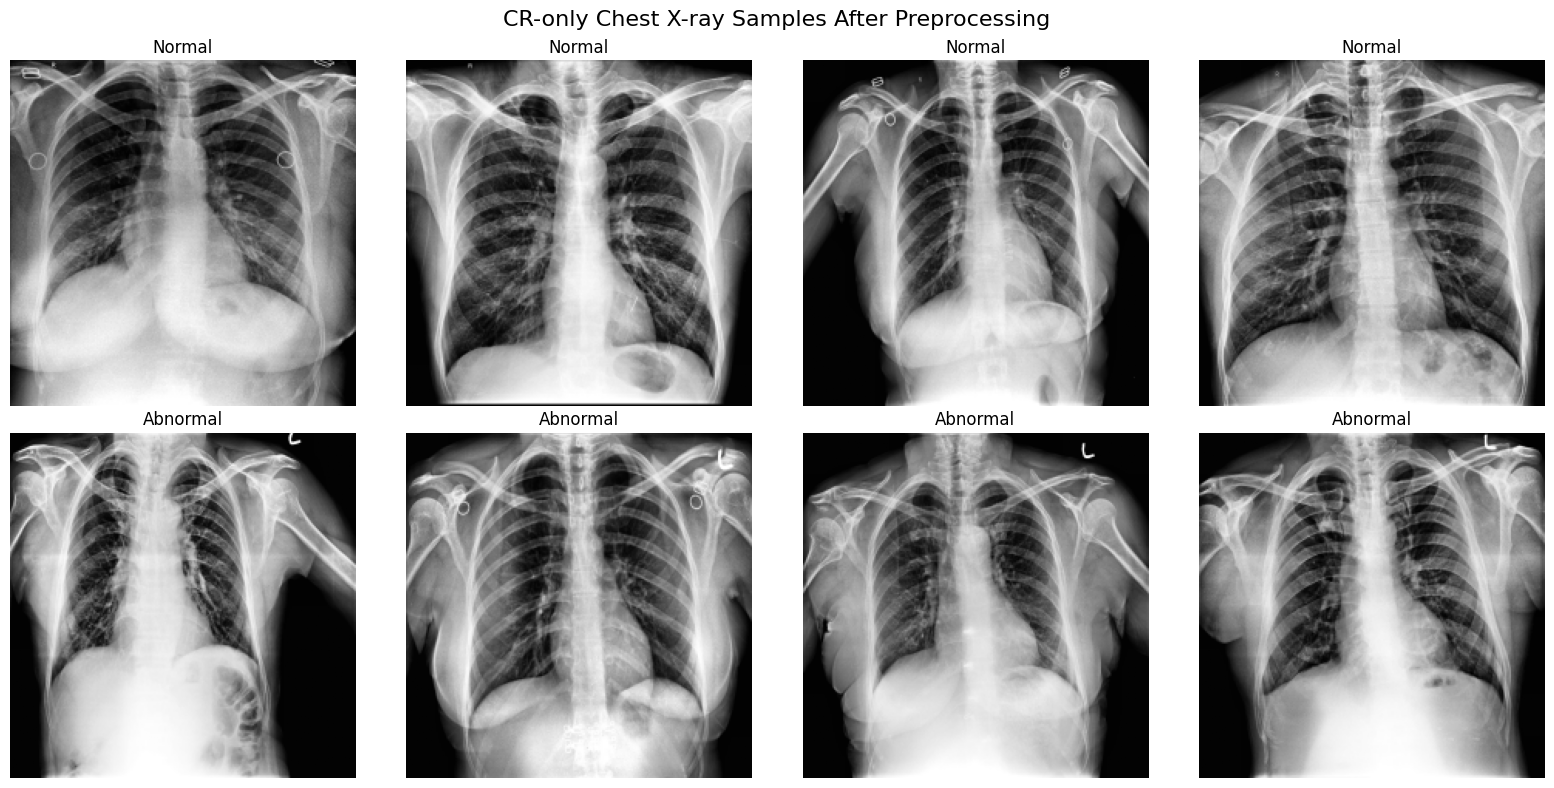

In [61]:
# ============================================================
# STEP 6: VISUAL SANITY CHECK
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Select 4 Normal and 4 Abnormal images
normal_samples = train_df[
    train_df["target"] == 1
].sample(
    n=4,
    random_state=42
)

abnormal_samples = train_df[
    train_df["target"] == 0
].sample(
    n=4,
    random_state=42
)

samples = pd.concat([
    normal_samples,
    abnormal_samples
]).reset_index(drop=True)


# ------------------------------------------------------------
# ImageNet normalization values
# ------------------------------------------------------------

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

for i, (_, row) in enumerate(samples.iterrows()):

    image = preprocess_dicom(
        row["path"],
        img_size=224
    )

    # Convert uint8 RGB to displayable image
    image_display = image.astype(np.float32) / 255.0

    ax = axes[i // 4, i % 4]

    ax.imshow(
        image_display,
        cmap="gray"
    )

    label = row["label"]

    ax.set_title(
        f"{label}",
        fontsize=12
    )

    ax.axis("off")


plt.suptitle(
    "CR-only Chest X-ray Samples After Preprocessing",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# STEP 7: AHF-NET INITIALIZATION + FORWARD PASS
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import timm

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# Adaptive Fusion Module
# ============================================================

class AdaptiveFusion(nn.Module):

    def __init__(self, dim=512):

        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.ReLU(inplace=True),
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, vit_feat):

        joint = torch.cat(
            [cnn_feat, vit_feat],
            dim=1
        )

        weight = self.attention(joint)

        fused = (
            weight * cnn_feat
            + (1 - weight) * vit_feat
        )

        return fused, weight


# ============================================================
# AHF-Net
# ============================================================

class AHFNet(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        # ----------------------------------------------------
        # CNN branch
        # ----------------------------------------------------

        self.cnn = timm.create_model(
            "densenet121",
            pretrained=True,
            num_classes=0
        )

        # ----------------------------------------------------
        # Transformer branch
        # ----------------------------------------------------

        self.vit = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

        # ----------------------------------------------------
        # Feature dimensions
        # ----------------------------------------------------

        cnn_dim = self.cnn.num_features
        vit_dim = self.vit.num_features

        print("DenseNet feature dimension:", cnn_dim)
        print("Swin feature dimension    :", vit_dim)

        # ----------------------------------------------------
        # Projection layers
        # ----------------------------------------------------

        self.cnn_projection = nn.Linear(
            cnn_dim,
            512
        )

        self.vit_projection = nn.Linear(
            vit_dim,
            512
        )

        # ----------------------------------------------------
        # Adaptive fusion
        # ----------------------------------------------------

        self.fusion = AdaptiveFusion(
            dim=512
        )

        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(512, 256),

            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )


    def forward(self, x):

        # CNN features
        cnn_feat = self.cnn(x)

        # Transformer features
        vit_feat = self.vit(x)

        # Project to common dimension
        cnn_feat = self.cnn_projection(
            cnn_feat
        )

        vit_feat = self.vit_projection(
            vit_feat
        )

        # Adaptive fusion
        fused_feat, fusion_weights = self.fusion(
            cnn_feat,
            vit_feat
        )

        # Classification
        logits = self.classifier(
            fused_feat
        )

        return logits, fusion_weights


# ============================================================
# Create model
# ============================================================

model = AHFNet(
    num_classes=2
).to(device)


print("\nModel created successfully.")


# ============================================================
# Count parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")


# ============================================================
# Class weights
# ============================================================

counts = (
    train_df["target"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    counts.sum() / counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("\nTraining class counts:")
print("Class 0 (Abnormal):", counts[0])
print("Class 1 (Normal)  :", counts[1])

print("\nClass weights:")
print(class_weights)


# ============================================================
# Loss
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# ============================================================
# Scheduler
# ============================================================

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)


# ============================================================
# Forward-pass test
# ============================================================

model.eval()

with torch.no_grad():

    images, targets = next(
        iter(train_loader)
    )

    images = images.to(
        device,
        non_blocking=True
    )

    targets = targets.to(
        device,
        non_blocking=True
    )

    outputs = model(images)

    logits = outputs[0]
    fusion_weights = outputs[1]


print("\n" + "=" * 60)
print("FORWARD PASS CHECK")
print("=" * 60)

print("Input shape          :", images.shape)
print("Target shape         :", targets.shape)
print("Logits shape         :", logits.shape)
print("Fusion weights shape :", fusion_weights.shape)

print("\nLogits finite:",
      torch.isfinite(logits).all().item())

print("Fusion finite:",
      torch.isfinite(fusion_weights).all().item())

print(
    "Fusion range:",
    fusion_weights.min().item(),
    "to",
    fusion_weights.max().item()
)


# ============================================================
# Loss test
# ============================================================

loss = criterion(
    logits,
    targets
)

print("\nInitial batch loss:", loss.item())

print(
    "Loss finite:",
    torch.isfinite(loss).item()
)

Device: cuda
DenseNet feature dimension: 1024
Swin feature dimension    : 768

Model created successfully.

Total parameters    : 36,311,036
Trainable parameters: 36,311,036

Training class counts:
Class 0 (Abnormal): 305
Class 1 (Normal)  : 544

Class weights:
tensor([2.7836, 1.5607], device='cuda:0')

FORWARD PASS CHECK
Input shape          : torch.Size([16, 3, 224, 224])
Target shape         : torch.Size([16])
Logits shape         : torch.Size([16, 2])
Fusion weights shape : torch.Size([16, 512])

Logits finite: True
Fusion finite: True
Fusion range: 0.39383408427238464 to 0.6083487868309021

Initial batch loss: 0.6945265531539917
Loss finite: True


In [63]:
# ============================================================
# STEP 8: AHF-NET FORWARD PASS + LOSS TEST
# ============================================================

model.eval()

with torch.no_grad():

    images, targets = next(iter(train_loader))

    images = images.to(
        device,
        non_blocking=True
    )

    targets = targets.to(
        device,
        non_blocking=True
    )

    outputs = model(images)

    # AHF-Net returns:
    # outputs[0] = logits
    # outputs[1] = adaptive fusion weights

    logits = outputs[0]
    fusion_weights = outputs[1]


print("=" * 60)
print("FORWARD PASS CHECK")
print("=" * 60)

print("Input shape          :", images.shape)
print("Target shape         :", targets.shape)
print("Logits shape         :", logits.shape)
print("Fusion weights shape :", fusion_weights.shape)

print("\nLogits finite:",
      torch.isfinite(logits).all().item())

print("Fusion finite:",
      torch.isfinite(fusion_weights).all().item())

print(
    "Fusion range:",
    fusion_weights.min().item(),
    "to",
    fusion_weights.max().item()
)


# ------------------------------------------------------------
# Loss test
# ------------------------------------------------------------

loss = criterion(
    logits,
    targets
)

print("\nInitial batch loss:", loss.item())

print(
    "Loss finite:",
    torch.isfinite(loss).item()
)


# ------------------------------------------------------------
# Prediction test
# ------------------------------------------------------------

probabilities = torch.softmax(
    logits,
    dim=1
)

predictions = torch.argmax(
    probabilities,
    dim=1
)

print("\nPrediction shape:", predictions.shape)

print(
    "Unique predictions:",
    torch.unique(predictions)
)

print(
    "Mean confidence:",
    probabilities.max(dim=1).values.mean().item()
)

FORWARD PASS CHECK
Input shape          : torch.Size([16, 3, 224, 224])
Target shape         : torch.Size([16])
Logits shape         : torch.Size([16, 2])
Fusion weights shape : torch.Size([16, 512])

Logits finite: True
Fusion finite: True
Fusion range: 0.3832586407661438 to 0.6117192506790161

Initial batch loss: 0.6926100850105286
Loss finite: True

Prediction shape: torch.Size([16])
Unique predictions: tensor([0, 1], device='cuda:0')
Mean confidence: 0.518778920173645


In [64]:
# ============================================================
# STEP 9: ONE-EPOCH AHF-NET SANITY TRAINING
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Training function
# ------------------------------------------------------------

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Mixed precision
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type="cuda",
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)

            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs

            loss = criterion(
                logits,
                targets
            )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_acc = accuracy_score(
        all_targets,
        all_preds
    )

    return epoch_loss, epoch_acc


# ------------------------------------------------------------
# Validation function
# ------------------------------------------------------------

def evaluate_model(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                enabled=(device.type == "cuda")
            ):

                outputs = model(images)

                if isinstance(outputs, tuple):
                    logits = outputs[0]
                else:
                    logits = outputs

                loss = criterion(
                    logits,
                    targets
                )

            running_loss += (
                loss.item() * images.size(0)
            )

            probs = torch.softmax(
                logits,
                dim=1
            )

            preds = torch.argmax(
                probs,
                dim=1
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            # Probability of class 0 = Abnormal
            all_probs.extend(
                probs[:, 0].cpu().numpy()
            )

    val_loss = (
        running_loss / len(loader.dataset)
    )

    val_acc = accuracy_score(
        all_targets,
        all_preds
    )

    val_precision = precision_score(
        all_targets,
        all_preds,
        pos_label=0,
        zero_division=0
    )

    val_recall = recall_score(
        all_targets,
        all_preds,
        pos_label=0,
        zero_division=0
    )

    val_f1 = f1_score(
        all_targets,
        all_preds,
        pos_label=0,
        zero_division=0
    )

    try:

        val_auc = roc_auc_score(
            all_targets,
            1 - np.array(all_probs)
        )

    except Exception:

        val_auc = np.nan

    return {
        "loss": val_loss,
        "accuracy": val_acc,
        "precision": val_precision,
        "recall": val_recall,
        "f1": val_f1,
        "auc": val_auc
    }


# ============================================================
# Create AMP scaler
# ============================================================

try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(device.type == "cuda")
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=(device.type == "cuda")
    )


# ============================================================
# Train exactly ONE epoch
# ============================================================

print("=" * 60)
print("STARTING ONE-EPOCH SANITY TRAINING")
print("=" * 60)

train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    scaler
)

val_results = evaluate_model(
    model,
    val_loader,
    criterion
)


print("\n" + "=" * 60)
print("ONE-EPOCH RESULTS")
print("=" * 60)

print(
    f"Train Loss      : {train_loss:.4f}"
)

print(
    f"Train Accuracy  : {train_acc:.4f}"
)

print(
    f"Val Loss        : {val_results['loss']:.4f}"
)

print(
    f"Val Accuracy    : {val_results['accuracy']:.4f}"
)

print(
    f"Val Precision   : {val_results['precision']:.4f}"
)

print(
    f"Val Recall      : {val_results['recall']:.4f}"
)

print(
    f"Val F1          : {val_results['f1']:.4f}"
)

print(
    f"Val AUC         : {val_results['auc']:.4f}"
)

STARTING ONE-EPOCH SANITY TRAINING

ONE-EPOCH RESULTS
Train Loss      : 0.3007
Train Accuracy  : 0.8975
Val Loss        : 0.1477
Val Accuracy    : 0.9151
Val Precision   : 0.8085
Val Recall      : 1.0000
Val F1          : 0.8941
Val AUC         : 0.9992


The important change is that after removing all DX images, performance dropped from the previous near-perfect result, but AUC is still extremely high (0.9992) after only one epoch.

That means we should perform one additional leakage/similarity check before committing to the 20-epoch experiment.

The biggest remaining concern is that the labels still correspond to two different original directories:

~ intbtr207 → Normal
~ intbtr251 → Abnormal

Even though we restricted the data to CR, the images may still contain dataset/source-specific characteristics.

In [65]:
# ============================================================
# STEP 10: IMAGE-LEVEL STATISTICS SANITY CHECK
# ============================================================

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def calculate_image_statistics(dataframe, max_images=None):

    df = dataframe.copy()

    if max_images is not None:
        df = df.sample(
            min(max_images, len(df)),
            random_state=42
        )

    records = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Analyzing images"
    ):

        try:

            img = preprocess_dicom(
                row["path"],
                img_size=224
            )

            gray = cv2.cvtColor(
                img,
                cv2.COLOR_RGB2GRAY
            )

            records.append({
                "label": row["label"],
                "target": int(row["target"]),
                "mean": float(gray.mean()),
                "std": float(gray.std()),
                "min": int(gray.min()),
                "max": int(gray.max()),
                "median": float(np.median(gray)),
                "p10": float(np.percentile(gray, 10)),
                "p90": float(np.percentile(gray, 90))
            })

        except Exception as e:
            pass

    return pd.DataFrame(records)


# Analyze the complete CR-only dataset
stats_df = calculate_image_statistics(
    cr_df
)

print("=" * 70)
print("IMAGE STATISTICS BY CLASS")
print("=" * 70)

print(
    stats_df.groupby("label")[
        ["mean", "std", "min", "max", "median", "p10", "p90"]
    ].agg(["mean", "std"])
)

Analyzing images:   0%|          | 0/1062 [00:00<?, ?it/s]

IMAGE STATISTICS BY CLASS
                mean                   std                 min            \
                mean        std       mean       std      mean       std   
label                                                                      
Abnormal  122.891983  14.025721  80.390275  8.388854  1.406824  0.502474   
Normal    129.644326  11.850021  72.044301  5.688912  1.559471  0.499767   

                max                median                   p10             \
               mean       std        mean        std       mean        std   
label                                                                        
Abnormal  255.00000  0.000000  130.573491  20.876765   6.417323   9.536998   
Normal    254.77533  0.722155  135.726872  15.397584  24.350954  16.141134   

                 p90             
                mean        std  
label                            
Abnormal  226.444882  15.608899  
Normal    222.512482   9.569494  


In [66]:
# ============================================================
# STEP 10B: STATISTICAL COMPARISON
# ============================================================

from scipy.stats import mannwhitneyu

features = [
    "mean",
    "std",
    "median",
    "p10",
    "p90"
]

print("=" * 70)
print("STATISTICAL COMPARISON: NORMAL vs ABNORMAL")
print("=" * 70)

normal = stats_df[
    stats_df["target"] == 1
]

abnormal = stats_df[
    stats_df["target"] == 0
]

for feature in features:

    stat, p = mannwhitneyu(
        normal[feature],
        abnormal[feature],
        alternative="two-sided"
    )

    print(
        f"{feature:>8} | "
        f"Normal mean = {normal[feature].mean():8.3f} | "
        f"Abnormal mean = {abnormal[feature].mean():8.3f} | "
        f"p = {p:.6e}"
    )

STATISTICAL COMPARISON: NORMAL vs ABNORMAL
    mean | Normal mean =  129.644 | Abnormal mean =  122.892 | p = 2.056208e-16
     std | Normal mean =   72.044 | Abnormal mean =   80.390 | p = 8.050290e-55
  median | Normal mean =  135.727 | Abnormal mean =  130.573 | p = 4.953462e-07
     p10 | Normal mean =   24.351 | Abnormal mean =    6.417 | p = 4.147143e-74
     p90 | Normal mean =  222.512 | Abnormal mean =  226.445 | p = 5.967703e-04


In [67]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import numpy as np

print("=" * 70)
print("IMAGE-STATISTICS BASELINE")
print("=" * 70)

feature_cols = [
    "mean",
    "std",
    "median",
    "p10",
    "p90"
]

X = stats_df[feature_cols].values
y = stats_df["target"].values

print("Samples:", len(X))
print("Features:", feature_cols)
print("Class distribution:")
print(pd.Series(y).value_counts().sort_index())

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

auc_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

acc_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

f1_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("\n5-FOLD CROSS-VALIDATION")
print("-" * 70)

print(
    f"AUC      : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}"
)

print(
    f"Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}"
)

print(
    f"F1       : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}"
)

IMAGE-STATISTICS BASELINE
Samples: 1062
Features: ['mean', 'std', 'median', 'p10', 'p90']
Class distribution:
0    381
1    681
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION
----------------------------------------------------------------------
AUC      : 0.8563 ± 0.0305
Accuracy : 0.7890 ± 0.0309
F1       : 0.8354 ± 0.0235


In [68]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("INDIVIDUAL IMAGE-STATISTIC PREDICTIVE POWER")
print("=" * 70)

for feature in feature_cols:

    X_single = stats_df[[feature]].values

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ])

    auc = cross_val_score(
        model,
        X_single,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    print(
        f"{feature:>8} | "
        f"AUC = {auc.mean():.4f} ± {auc.std():.4f}"
    )

INDIVIDUAL IMAGE-STATISTIC PREDICTIVE POWER
    mean | AUC = 0.6523 ± 0.0281
     std | AUC = 0.7874 ± 0.0320
  median | AUC = 0.5934 ± 0.0357
     p10 | AUC = 0.8213 ± 0.0223
     p90 | AUC = 0.5632 ± 0.0425


In [69]:
print("=" * 70)
print("SOURCE / FILENAME ASSOCIATION CHECK")
print("=" * 70)

tmp = cr_df.copy()

tmp["folder"] = tmp["path"].apply(
    lambda x: str(x).split("/")[-2]
)

tmp["filename"] = tmp["path"].apply(
    lambda x: str(x).split("/")[-1]
)

print("\nFolder distribution by class:")
print(
    pd.crosstab(
        tmp["label"],
        tmp["folder"]
    )
)

print("\nFilename suffix distribution:")
print(
    tmp["filename"].str.extract(
        r"_(Normal|Abnormal)\.dicom$"
    )[0].value_counts()
)

print("\nFilename suffix vs target:")
print(
    pd.crosstab(
        tmp["target"],
        tmp["filename"].str.extract(
            r"_(Normal|Abnormal)\.dicom$"
        )[0]
    )
)

SOURCE / FILENAME ASSOCIATION CHECK

Folder distribution by class:
folder    intbtr207  intbtr251
label                         
Abnormal          0        381
Normal          681          0

Filename suffix distribution:
0
Normal      681
Abnormal    381
Name: count, dtype: int64

Filename suffix vs target:
0       Abnormal  Normal
target                  
0            381       0
1              0     681


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 70)
print("IMAGE-STATISTICS TRAIN/TEST BASELINE")
print("=" * 70)

feature_cols = [
    "mean",
    "std",
    "median",
    "p10",
    "p90"
]

# Identify statistics belonging to each split
train_paths = set(train_df["path"])
test_paths = set(test_df["path"])

stats_train = stats_df[
    stats_df["path"].isin(train_paths)
].copy() if "path" in stats_df.columns else None

IMAGE-STATISTICS TRAIN/TEST BASELINE


In [71]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def calculate_image_statistics_with_path(dataframe):

    df = dataframe.copy()

    records = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Analyzing CR images"
    ):

        try:

            img = preprocess_dicom(
                row["path"],
                img_size=224
            )

            gray = cv2.cvtColor(
                img,
                cv2.COLOR_RGB2GRAY
            )

            records.append({
                "path": row["path"],
                "label": row["label"],
                "target": int(row["target"]),
                "mean": float(gray.mean()),
                "std": float(gray.std()),
                "median": float(np.median(gray)),
                "p10": float(np.percentile(gray, 10)),
                "p90": float(np.percentile(gray, 90))
            })

        except Exception as e:
            print("Failed:", row["path"], "|", e)

    return pd.DataFrame(records)


stats_df = calculate_image_statistics_with_path(cr_df)

print("\nStatistics dataframe:")
print(stats_df.shape)

print("\nColumns:")
print(stats_df.columns.tolist())

Analyzing CR images:   0%|          | 0/1062 [00:00<?, ?it/s]


Statistics dataframe:
(1062, 8)

Columns:
['path', 'label', 'target', 'mean', 'std', 'median', 'p10', 'p90']


In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

feature_cols = [
    "mean",
    "std",
    "median",
    "p10",
    "p90"
]

train_paths = set(train_df["path"])
test_paths = set(test_df["path"])

stats_train = stats_df[
    stats_df["path"].isin(train_paths)
].copy()

stats_test = stats_df[
    stats_df["path"].isin(test_paths)
].copy()

X_train = stats_train[feature_cols].values
y_train = stats_train["target"].values

X_test = stats_test[feature_cols].values
y_test = stats_test["target"].values

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

baseline.fit(X_train, y_train)

test_pred = baseline.predict(X_test)
test_prob = baseline.predict_proba(X_test)[:, 1]

print("=" * 70)
print("IMAGE-STATISTICS TEST PERFORMANCE")
print("=" * 70)

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

print(f"\nAccuracy  : {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision : {precision_score(y_test, test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, test_pred):.4f}")
print(f"F1        : {f1_score(y_test, test_pred):.4f}")
print(f"AUC       : {roc_auc_score(y_test, test_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

IMAGE-STATISTICS TEST PERFORMANCE
Train samples: 849
Test samples : 107

Accuracy  : 0.7664
Precision : 0.8333
Recall    : 0.7971
F1        : 0.8148
AUC       : 0.8513

Confusion Matrix:
[[27 11]
 [14 55]]


In [73]:
# ============================================================
# STEP 14 — AHF-NET: 20-EPOCH MAIN TRAINING
# ============================================================

import os
import gc
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 2. Re-create model
# ------------------------------------------------------------

model = AHFNet(
    num_classes=2
).to(device)

print("\nModel created.")
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


# ------------------------------------------------------------
# 3. Class-weighted loss
# ------------------------------------------------------------

counts = (
    train_df["target"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    counts.sum() / counts
).astype(np.float32)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("\nClass counts:", counts)
print("Class weights:", class_weights)


# ------------------------------------------------------------
# 4. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)


# ------------------------------------------------------------
# 5. AMP
# ------------------------------------------------------------

scaler = torch.cuda.amp.GradScaler(
    enabled=torch.cuda.is_available()
)


# ------------------------------------------------------------
# 6. Training function
# ------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):

    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.cuda.amp.autocast(
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs

            loss = criterion(
                logits,
                targets
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_acc = accuracy_score(
        all_targets,
        all_preds
    )

    return epoch_loss, epoch_acc


# ------------------------------------------------------------
# 7. Validation function
# ------------------------------------------------------------

def evaluate_model(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            with torch.cuda.amp.autocast(
                enabled=torch.cuda.is_available()
            ):

                outputs = model(images)

                if isinstance(outputs, tuple):
                    logits = outputs[0]
                else:
                    logits = outputs

                loss = criterion(
                    logits,
                    targets
                )

            running_loss += (
                loss.item() * images.size(0)
            )

            probs = torch.softmax(
                logits,
                dim=1
            )

            preds = torch.argmax(
                logits,
                dim=1
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    all_targets = np.array(
        all_targets
    )

    all_preds = np.array(
        all_preds
    )

    all_probs = np.array(
        all_probs
    )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    # target=1 is Normal in the current dataset encoding
    auc = roc_auc_score(
        all_targets,
        all_probs[:, 1]
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }


# ------------------------------------------------------------
# 8. Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 20

best_auc = -np.inf
best_epoch = 0
best_state = None

history = []

checkpoint_path = (
    "/kaggle/working/"
    "AHFNet_CR_best.pth"
)


# ------------------------------------------------------------
# 9. Training loop
# ------------------------------------------------------------

print("\n")
print("=" * 100)
print("STARTING AHF-NET TRAINING")
print("=" * 100)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    scheduler.step()

    history.append({
        "epoch": epoch,
        "lr": current_lr,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    # --------------------------------------------------------
    # Save only best validation AUC
    # --------------------------------------------------------

    if val_metrics["auc"] > best_auc:

        best_auc = val_metrics["auc"]
        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "val_auc": best_auc
            },
            checkpoint_path
        )

        marker = "  <-- BEST"

    else:

        marker = ""

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f}"
        f"{marker}"
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# 10. Load best model
# ------------------------------------------------------------

if best_state is not None:

    model.load_state_dict(
        best_state
    )

print("\n")
print("=" * 100)
print("TRAINING COMPLETED")
print("=" * 100)

print(
    f"Best validation AUC : {best_auc:.4f}"
)

print(
    f"Best epoch          : {best_epoch}"
)

print(
    f"Checkpoint saved at : {checkpoint_path}"
)


# ------------------------------------------------------------
# 11. History dataframe
# ------------------------------------------------------------

history_df = pd.DataFrame(
    history
)

print("\nTraining history:")
display(history_df)


# ------------------------------------------------------------
# 12. Final validation result
# ------------------------------------------------------------

best_val_metrics = evaluate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n")
print("=" * 70)
print("BEST MODEL — VALIDATION PERFORMANCE")
print("=" * 70)

print(
    f"Loss      : {best_val_metrics['loss']:.4f}"
)

print(
    f"Accuracy  : {best_val_metrics['accuracy']:.4f}"
)

print(
    f"Precision : {best_val_metrics['precision']:.4f}"
)

print(
    f"Recall    : {best_val_metrics['recall']:.4f}"
)

print(
    f"F1        : {best_val_metrics['f1']:.4f}"
)

print(
    f"AUC       : {best_val_metrics['auc']:.4f}"
)

Device: cuda
GPU: Tesla T4
DenseNet feature dimension: 1024
Swin feature dimension    : 768

Model created.
Trainable parameters: 36311036

Class counts: [305 544]
Class weights: tensor([2.7836, 1.5607], device='cuda:0')


STARTING AHF-NET TRAINING


/tmp/ipykernel_58/3765498676.py:98: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(
/tmp/ipykernel_58/3765498676.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
/tmp/ipykernel_58/3765498676.py:210: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


RuntimeError: [enforce fail at inline_container.cc:668] . unexpected pos 64 vs 0

In [74]:
import os
import shutil

print("=" * 70)
print("KAGGLE DISK SPACE")
print("=" * 70)

total, used, free = shutil.disk_usage("/kaggle/working")

print(f"Total : {total / (1024**3):.2f} GB")
print(f"Used  : {used / (1024**3):.2f} GB")
print(f"Free  : {free / (1024**3):.2f} GB")

print("\nFiles in /kaggle/working:")

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        path = os.path.join(root, file)
        size = os.path.getsize(path) / (1024**2)
        print(f"{size:8.2f} MB  {path}")

KAGGLE DISK SPACE
Total : 19.52 GB
Used  : 19.50 GB
Free  : 0.00 GB

Files in /kaggle/working:
    0.00 MB  /kaggle/working/best_AHFNet.pth
    0.00 MB  /kaggle/working/AHFNet_CR_best.pth
    0.00 MB  /kaggle/working/best_AHFNet_tmp.pth
 6816.82 MB  /kaggle/working/chestdoc/chestdoc.zip
    6.56 MB  /kaggle/working/chestdoc/data/PostDoc/intbtr207/intbtr207/59398ecc1d4af95a37dd4e2f852e7140_Normal.dicom
    7.26 MB  /kaggle/working/chestdoc/data/PostDoc/intbtr207/intbtr207/56a80c990e6328949d0685b4e8f3711e_Normal.dicom
    9.38 MB  /kaggle/working/chestdoc/data/PostDoc/intbtr207/intbtr207/88bc9105369e6921f8e4461de4ed7b1f_Normal.dicom
    4.97 MB  /kaggle/working/chestdoc/data/PostDoc/intbtr207/intbtr207/18326c6faacb5984d4f269d235e0f6f1_Normal.dicom
    6.58 MB  /kaggle/working/chestdoc/data/PostDoc/intbtr207/intbtr207/010e3f96e17a1f804979fe19f8e2872e_Normal.dicom
    5.89 MB  /kaggle/working/chestdoc/data/PostDoc/intbtr207/intbtr207/72e2b43229493fca249c78c58672f7b7_Normal.dicom
    5.49 M

In [75]:
import os

checkpoint_path = "/kaggle/working/AHFNet_CR_best.pth"

if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)
    print("Removed failed checkpoint.")
else:
    print("No checkpoint found.")

import gc
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Cleanup completed.")

Removed failed checkpoint.
Cleanup completed.


In [82]:
# ============================================================
# STEP 14 — AHF-NET 20-EPOCH MAIN TRAINING
# CR-ONLY DATASET
# AMP UPDATED FOR CURRENT PYTORCH
# NO CHECKPOINT SAVING DURING TRAINING
# ============================================================

import os
import gc
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("DEVICE INFORMATION")
print("=" * 80)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "CUDA memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB"
    )


# ============================================================
# 2. CLEAR GPU MEMORY
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleanup completed.")


# ============================================================
# 3. CREATE AHF-NET
# ============================================================

model = AHFNet(
    num_classes=2
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\n" + "=" * 80)
print("AHF-NET MODEL")
print("=" * 80)

print(
    f"Total parameters     : {total_params:,}"
)

print(
    f"Trainable parameters : {trainable_params:,}"
)


# ============================================================
# 4. CLASS-WEIGHTED CROSS ENTROPY
# ============================================================

counts = (
    train_df["target"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    counts.sum() / counts
).astype(np.float32)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("\n" + "=" * 80)
print("LOSS FUNCTION")
print("=" * 80)

print("Class counts:", counts)
print("Class weights:", class_weights.detach().cpu().numpy())

print("\nCurrent label mapping:")
print("Target 0 = Abnormal")
print("Target 1 = Normal")


# ============================================================
# 5. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# ============================================================
# 6. COSINE ANNEALING SCHEDULER
# ============================================================

NUM_EPOCHS = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)


# ============================================================
# 7. CURRENT PYTORCH AMP
# ============================================================

use_amp = torch.cuda.is_available()

if use_amp:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=True
    )

else:

    scaler = torch.amp.GradScaler(
        "cpu",
        enabled=False
    )

print("\nAMP enabled:", use_amp)


# ============================================================
# 8. TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    all_targets = []
    all_preds = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # CURRENT PYTORCH AMP API
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_amp
        ):

            outputs = model(images)

            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs

            loss = criterion(
                logits,
                targets
            )

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        # ----------------------------------------------------
        # STATISTICS
        # ----------------------------------------------------

        running_loss += (
            loss.item() *
            images.size(0)
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    return (
        epoch_loss,
        epoch_accuracy
    )


# ============================================================
# 9. VALIDATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # CURRENT PYTORCH AMP API
            # ------------------------------------------------

            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp
            ):

                outputs = model(images)

                if isinstance(outputs, tuple):
                    logits = outputs[0]
                else:
                    logits = outputs

                loss = criterion(
                    logits,
                    targets
                )

            running_loss += (
                loss.item() *
                images.size(0)
            )

            probs = torch.softmax(
                logits,
                dim=1
            )

            preds = torch.argmax(
                logits,
                dim=1
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    # --------------------------------------------------------
    # CONVERT TO NUMPY
    # --------------------------------------------------------

    all_targets = np.asarray(
        all_targets
    )

    all_preds = np.asarray(
        all_preds
    )

    all_probs = np.asarray(
        all_probs
    )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    # --------------------------------------------------------
    # IMPORTANT:
    #
    # Current encoding:
    # 0 = Abnormal
    # 1 = Normal
    #
    # Therefore class-1 probability is used for ROC-AUC.
    # --------------------------------------------------------

    auc = roc_auc_score(
        all_targets,
        all_probs[:, 1]
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }


# ============================================================
# 10. TRAINING VARIABLES
# ============================================================

best_auc = -np.inf
best_epoch = 0
best_state = None

history = []


# ============================================================
# 11. MAIN TRAINING LOOP
# ============================================================

print("\n")
print("=" * 100)
print("STARTING AHF-NET TRAINING")
print("=" * 100)

print(
    f"Epochs        : {NUM_EPOCHS}"
)

print(
    f"Learning rate : {optimizer.param_groups[0]['lr']}"
)

print(
    f"Train samples : {len(train_loader.dataset)}"
)

print(
    f"Val samples   : {len(val_loader.dataset)}"
)

print("=" * 100)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_metrics = evaluate_model(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    # --------------------------------------------------------
    # CURRENT LEARNING RATE
    # --------------------------------------------------------

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # --------------------------------------------------------
    # UPDATE SCHEDULER
    # --------------------------------------------------------

    scheduler.step()

    # --------------------------------------------------------
    # STORE HISTORY
    # --------------------------------------------------------

    history.append({

        "epoch": epoch,

        "learning_rate": current_lr,

        "train_loss": train_loss,

        "train_accuracy": train_acc,

        "val_loss": val_metrics["loss"],

        "val_accuracy": val_metrics["accuracy"],

        "val_precision": val_metrics["precision"],

        "val_recall": val_metrics["recall"],

        "val_f1": val_metrics["f1"],

        "val_auc": val_metrics["auc"]

    })

    # --------------------------------------------------------
    # KEEP BEST MODEL IN RAM
    #
    # NO torch.save() HERE
    # --------------------------------------------------------

    if val_metrics["auc"] > best_auc:

        best_auc = val_metrics["auc"]

        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )

        marker = "  <-- BEST"

    else:

        marker = ""

    # --------------------------------------------------------
    # PRINT EPOCH RESULT
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f}"
        f"{marker}"
    )

    # --------------------------------------------------------
    # MEMORY CLEANUP
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 12. RESTORE BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )

    print("\nBest model restored from RAM.")


# ============================================================
# 13. FINAL BEST VALIDATION EVALUATION
# ============================================================

best_val_metrics = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device
)


# ============================================================
# 14. TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("AHF-NET TRAINING COMPLETED")
print("=" * 100)

print(
    f"Best Epoch          : {best_epoch}"
)

print(
    f"Best Validation AUC : {best_auc:.4f}"
)

print("\n")
print("BEST VALIDATION PERFORMANCE")
print("-" * 70)

print(
    f"Loss      : {best_val_metrics['loss']:.4f}"
)

print(
    f"Accuracy  : {best_val_metrics['accuracy']:.4f}"
)

print(
    f"Precision : {best_val_metrics['precision']:.4f}"
)

print(
    f"Recall    : {best_val_metrics['recall']:.4f}"
)

print(
    f"F1        : {best_val_metrics['f1']:.4f}"
)

print(
    f"AUC       : {best_val_metrics['auc']:.4f}"
)

print("\n")
print("=" * 100)
print("TRAINING HISTORY")
print("=" * 100)

display(
    history_df
)


# ============================================================
# 16. CHECK BEST MODEL EXISTS IN MEMORY
# ============================================================

if best_state is not None:

    print("\nBest model state is available in memory.")
    print(
        "Best epoch:",
        best_epoch
    )

else:

    print(
        "\nWARNING: No best model state was recorded."
    )


# ============================================================
# 17. GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    allocated = (
        torch.cuda.memory_allocated()
        / (1024 ** 3)
    )

    reserved = (
        torch.cuda.memory_reserved()
        / (1024 ** 3)
    )

    print("\n")
    print("=" * 70)
    print("GPU MEMORY AFTER TRAINING")
    print("=" * 70)

    print(
        f"Allocated : {allocated:.2f} GB"
    )

    print(
        f"Reserved  : {reserved:.2f} GB"
    )

DEVICE INFORMATION
Device: cuda
GPU: Tesla T4
CUDA memory: 14.56 GB

GPU memory cleanup completed.
DenseNet feature dimension: 1024
Swin feature dimension    : 768

AHF-NET MODEL
Total parameters     : 36,311,036
Trainable parameters : 36,311,036

LOSS FUNCTION
Class counts: [305 544]
Class weights: [2.7836065 1.5606618]

Current label mapping:
Target 0 = Abnormal
Target 1 = Normal

AMP enabled: True


STARTING AHF-NET TRAINING
Epochs        : 20
Learning rate : 0.0001
Train samples : 849
Val samples   : 106
Epoch [01/20] | LR: 1.00e-04 | Train Loss: 0.2992 | Train Acc: 0.8952 | Val Loss: 0.2188 | Val Acc: 0.9623 | Val F1: 0.9701 | Val AUC: 0.9981  <-- BEST
Epoch [02/20] | LR: 9.94e-05 | Train Loss: 0.1466 | Train Acc: 0.9635 | Val Loss: 0.0155 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000  <-- BEST
Epoch [03/20] | LR: 9.76e-05 | Train Loss: 0.0310 | Train Acc: 0.9906 | Val Loss: 0.0007 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [04/20] | LR: 9.46e-05 | Train Los

,epoch,learning_rate,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,1,1.000000e-04,0.299191,0.895171,0.218761,0.962264,0.984848,0.955882,0.970149,0.998065
1,2,9.938442e-05,0.146624,0.963486,0.015486,1.000000,1.000000,1.000000,1.000000,1.000000
2,3,9.755283e-05,0.031017,0.990577,0.000679,1.000000,1.000000,1.000000,1.000000,1.000000
3,4,9.455033e-05,0.073708,0.977621,0.022842,1.000000,1.000000,1.000000,1.000000,1.000000
4,5,9.045085e-05,0.034823,0.990577,0.003606,1.000000,1.000000,1.000000,1.000000,1.000000
5,6,8.535534e-05,0.011837,0.996466,0.001029,1.000000,1.000000,1.000000,1.000000,1.000000
6,7,7.938926e-05,0.006991,0.998822,0.001987,1.000000,1.000000,1.000000,1.000000,1.000000
7,8,7.269952e-05,0.002400,1.000000,0.000182,1.000000,1.000000,1.000000,1.000000,1.000000
8,9,6.545085e-05,0.014015,0.996466,0.000988,1.000000,1.000000,1.000000,1.000000,1.000000
9,10,5.782172e-05,0.011609,0.996466,0.009274,1.000000,1.000000,1.000000,1.000000,1.000000



Best model state is available in memory.
Best epoch: 2


GPU MEMORY AFTER TRAINING
Allocated : 1.15 GB
Reserved  : 1.67 GB


STEP 15 — FINAL TEST-SET EVALUATION
Best epoch: 2
Best validation AUC: 1.0000

Test samples: 107

Current label mapping:
Target 0 = Abnormal
Target 1 = Normal

TEST INFERENCE SANITY CHECK
Targets shape : (107,)
Predictions   : (107,)
Probabilities : (107, 2)
Target classes: [0 1]
Predicted classes: [0 1]
Probability range: 0.0007977 to 0.999

FINAL AHF-NET TEST PERFORMANCE
Accuracy          : 1.0000
Precision         : 1.0000
Recall            : 1.0000
Sensitivity       : 1.0000
Specificity       : 1.0000
F1-score          : 1.0000
ROC-AUC           : 1.0000
Average Precision : 1.0000

CONFUSION MATRIX

                Predicted
             Abnormal  Normal
Actual Abnormal     38        0
Actual Normal        0       69

Raw confusion matrix:
[[38  0]
 [ 0 69]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Abnormal     1.0000    1.0000    1.0000        38
      Normal     1.0000    1.0000    1.0000        69

    accuracy                         1.0

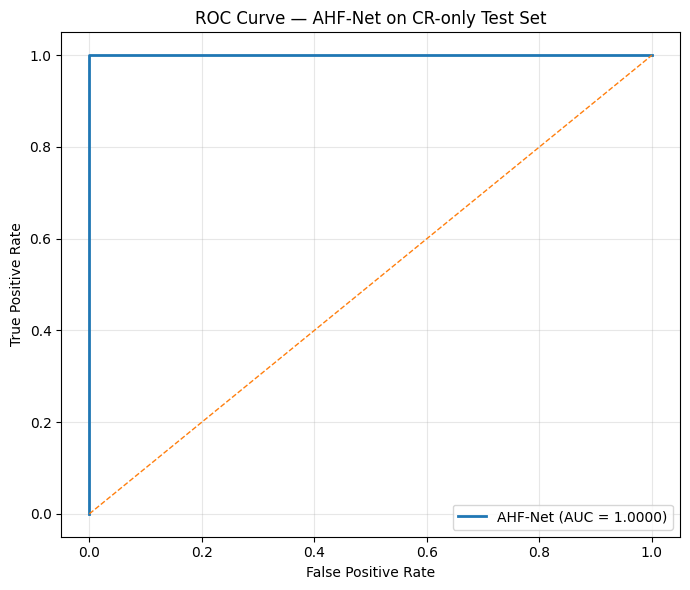

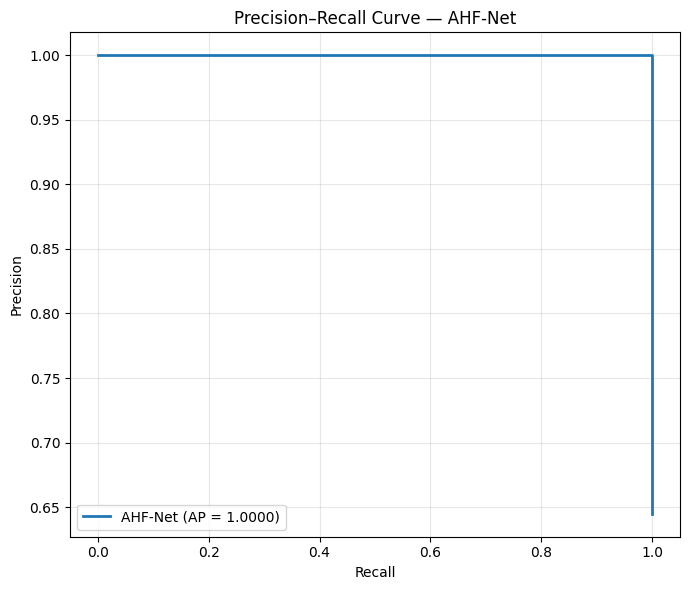


TEST RESULTS DATAFRAME


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,true_label,predicted_label,abnormal_probability,normal_probability,confidence,true_class,predicted_class,correct
0,1,1,0.019562,0.980469,0.980469,Normal,Normal,True
1,1,1,0.001916,0.998047,0.998047,Normal,Normal,True
2,1,1,0.006340,0.993652,0.993652,Normal,Normal,True
3,1,1,0.003443,0.996582,0.996582,Normal,Normal,True
4,0,0,0.945312,0.054504,0.945312,Abnormal,Abnormal,True
5,1,1,0.002678,0.997559,0.997559,Normal,Normal,True
6,1,1,0.003780,0.996094,0.996094,Normal,Normal,True
7,1,1,0.002796,0.997070,0.997070,Normal,Normal,True
8,1,1,0.004528,0.995605,0.995605,Normal,Normal,True
9,1,1,0.005707,0.994141,0.994141,Normal,Normal,True



Correct predictions: 107
Incorrect predictions: 0


In [83]:
# ============================================================
# STEP 15 — FINAL TEST-SET EVALUATION
# AHF-Net | CR-only Test Set
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# ------------------------------------------------------------
# 1. VERIFY BEST MODEL
# ------------------------------------------------------------

if best_state is None:
    raise RuntimeError(
        "best_state is None. The best trained model is not available in memory."
    )

model.load_state_dict(best_state)
model = model.to(device)
model.eval()

print("=" * 90)
print("STEP 15 — FINAL TEST-SET EVALUATION")
print("=" * 90)

print("Best epoch:", best_epoch)
print("Best validation AUC:", f"{best_auc:.4f}")

print("\nTest samples:", len(test_loader.dataset))

# ------------------------------------------------------------
# 2. LABEL MAPPING
# ------------------------------------------------------------

print("\nCurrent label mapping:")
print("Target 0 = Abnormal")
print("Target 1 = Normal")

# ------------------------------------------------------------
# 3. TEST INFERENCE
# ------------------------------------------------------------

test_targets = []
test_preds = []
test_probs = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_amp
        ):

            outputs = model(images)

            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs

        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(logits, dim=1)

        test_targets.extend(
            targets.cpu().numpy()
        )

        test_preds.extend(
            predictions.cpu().numpy()
        )

        test_probs.extend(
            probabilities.cpu().numpy()
        )

test_targets = np.asarray(test_targets)
test_preds = np.asarray(test_preds)
test_probs = np.asarray(test_probs)

# ------------------------------------------------------------
# 4. BASIC SANITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("TEST INFERENCE SANITY CHECK")
print("=" * 90)

print("Targets shape :", test_targets.shape)
print("Predictions   :", test_preds.shape)
print("Probabilities :", test_probs.shape)

print(
    "Target classes:",
    np.unique(test_targets)
)

print(
    "Predicted classes:",
    np.unique(test_preds)
)

print(
    "Probability range:",
    test_probs.min(),
    "to",
    test_probs.max()
)

# ------------------------------------------------------------
# 5. STANDARD METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    test_targets,
    test_preds
)

precision = precision_score(
    test_targets,
    test_preds,
    zero_division=0
)

recall = recall_score(
    test_targets,
    test_preds,
    zero_division=0
)

f1 = f1_score(
    test_targets,
    test_preds,
    zero_division=0
)

# Current class-1 probability corresponds to Normal
auc = roc_auc_score(
    test_targets,
    test_probs[:, 1]
)

# ------------------------------------------------------------
# 6. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    test_targets,
    test_preds,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

# ------------------------------------------------------------
# 7. AVERAGE PRECISION
# ------------------------------------------------------------

average_precision = average_precision_score(
    test_targets,
    test_probs[:, 1]
)

# ------------------------------------------------------------
# 8. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FINAL AHF-NET TEST PERFORMANCE")
print("=" * 90)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"Sensitivity       : {sensitivity:.4f}")
print(f"Specificity       : {specificity:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"ROC-AUC           : {auc:.4f}")
print(f"Average Precision : {average_precision:.4f}")

print("\n" + "=" * 90)
print("CONFUSION MATRIX")
print("=" * 90)

print(
    "\n                Predicted"
)
print(
    "             Abnormal  Normal"
)
print(
    f"Actual Abnormal   {tn:4d}     {fp:4d}"
)
print(
    f"Actual Normal     {fn:4d}     {tp:4d}"
)

print("\nRaw confusion matrix:")
print(cm)

# ------------------------------------------------------------
# 9. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("CLASSIFICATION REPORT")
print("=" * 90)

print(
    classification_report(
        test_targets,
        test_preds,
        labels=[0, 1],
        target_names=["Abnormal", "Normal"],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 10. TEST CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("TEST SET CLASS DISTRIBUTION")
print("=" * 90)

unique, counts = np.unique(
    test_targets,
    return_counts=True
)

for cls, count in zip(unique, counts):

    label = (
        "Abnormal"
        if cls == 0
        else "Normal"
    )

    print(
        f"{label:10s}: {count}"
    )

# ------------------------------------------------------------
# 11. CONFIDENCE ANALYSIS
# ------------------------------------------------------------

max_confidence = test_probs.max(axis=1)

print("\n" + "=" * 90)
print("PREDICTION CONFIDENCE")
print("=" * 90)

print(
    f"Mean confidence   : {max_confidence.mean():.4f}"
)

print(
    f"Median confidence : {np.median(max_confidence):.4f}"
)

print(
    f"Minimum confidence: {max_confidence.min():.4f}"
)

print(
    f"Maximum confidence: {max_confidence.max():.4f}"
)

# ------------------------------------------------------------
# 12. ROC CURVE
# ------------------------------------------------------------

fpr, tpr, roc_thresholds = roc_curve(
    test_targets,
    test_probs[:, 1]
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AHF-Net (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AHF-Net on CR-only Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. PRECISION-RECALL CURVE
# ------------------------------------------------------------

pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    test_targets,
    test_probs[:, 1]
)

plt.figure(figsize=(7, 6))

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"AHF-Net (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — AHF-Net")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. SAVE TEST RESULTS IN DATAFRAME
# ------------------------------------------------------------

test_results_df = pd.DataFrame({
    "true_label": test_targets,
    "predicted_label": test_preds,
    "abnormal_probability": test_probs[:, 0],
    "normal_probability": test_probs[:, 1],
    "confidence": max_confidence
})

test_results_df["true_class"] = test_results_df[
    "true_label"
].map({
    0: "Abnormal",
    1: "Normal"
})

test_results_df["predicted_class"] = test_results_df[
    "predicted_label"
].map({
    0: "Abnormal",
    1: "Normal"
})

test_results_df["correct"] = (
    test_results_df["true_label"]
    ==
    test_results_df["predicted_label"]
)

print("\n" + "=" * 90)
print("TEST RESULTS DATAFRAME")
print("=" * 90)

display(
    test_results_df.head(20)
)

print(
    "\nCorrect predictions:",
    test_results_df["correct"].sum()
)

print(
    "Incorrect predictions:",
    (~test_results_df["correct"]).sum()
)

In [84]:
# ============================================================
# STEP 16A — CR-ONLY DICOM METADATA / SOURCE AUDIT
# ============================================================

import os
import numpy as np
import pandas as pd
import pydicom

print("=" * 90)
print("STEP 16A — CR-ONLY METADATA / SOURCE AUDIT")
print("=" * 90)

# ------------------------------------------------------------
# 1. CHECK AVAILABLE COLUMNS
# ------------------------------------------------------------

print("\nCR dataframe columns:")
print(cr_df.columns.tolist())

# ------------------------------------------------------------
# 2. IDENTIFY PATH COLUMN
# ------------------------------------------------------------

possible_path_cols = [
    "path",
    "filepath",
    "file_path",
    "file",
    "filename"
]

path_col = None

for col in possible_path_cols:
    if col in cr_df.columns:
        path_col = col
        break

if path_col is None:
    raise ValueError(
        "Could not automatically identify the image path column."
    )

print("\nPath column:", path_col)

# ------------------------------------------------------------
# 3. BUILD METADATA TABLE
# ------------------------------------------------------------

metadata_records = []

for _, row in cr_df.iterrows():

    path = row[path_col]

    try:
        ds = pydicom.dcmread(
            path,
            stop_before_pixels=True
        )

        record = {
            "label": row["label"],
            "target": row["target"],
            "path": path,

            "Modality": str(
                getattr(ds, "Modality", "")
            ),

            "Manufacturer": str(
                getattr(ds, "Manufacturer", "")
            ),

            "ManufacturerModelName": str(
                getattr(ds, "ManufacturerModelName", "")
            ),

            "PatientPosition": str(
                getattr(ds, "PatientPosition", "")
            ),

            "ViewPosition": str(
                getattr(ds, "ViewPosition", "")
            ),

            "StudyDescription": str(
                getattr(ds, "StudyDescription", "")
            ),

            "SeriesDescription": str(
                getattr(ds, "SeriesDescription", "")
            ),

            "BodyPartExamined": str(
                getattr(ds, "BodyPartExamined", "")
            ),

            "PhotometricInterpretation": str(
                getattr(ds, "PhotometricInterpretation", "")
            ),

            "Rows": str(
                getattr(ds, "Rows", "")
            ),

            "Columns": str(
                getattr(ds, "Columns", "")
            ),

            "BitsAllocated": str(
                getattr(ds, "BitsAllocated", "")
            )
        }

        metadata_records.append(record)

    except Exception as e:

        metadata_records.append({
            "label": row["label"],
            "target": row["target"],
            "path": path,
            "read_error": str(e)
        })

metadata_df = pd.DataFrame(
    metadata_records
)

# ------------------------------------------------------------
# 4. BASIC SUMMARY
# ------------------------------------------------------------

print("\nMetadata dataframe shape:")
print(metadata_df.shape)

display(
    metadata_df.head()
)

# ------------------------------------------------------------
# 5. CHECK EACH METADATA FIELD
# ------------------------------------------------------------

metadata_cols = [
    "Modality",
    "Manufacturer",
    "ManufacturerModelName",
    "PatientPosition",
    "ViewPosition",
    "StudyDescription",
    "SeriesDescription",
    "BodyPartExamined",
    "PhotometricInterpretation",
    "Rows",
    "Columns",
    "BitsAllocated"
]

print("\n" + "=" * 90)
print("METADATA DISTRIBUTION BY CLASS")
print("=" * 90)

for col in metadata_cols:

    if col not in metadata_df.columns:
        continue

    print("\n" + "-" * 80)
    print(col)

    table = pd.crosstab(
        metadata_df["label"],
        metadata_df[col],
        margins=False
    )

    display(table)

# ------------------------------------------------------------
# 6. PATH / FOLDER STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("PATH / SOURCE STRUCTURE")
print("=" * 90)

metadata_df["parent_folder"] = metadata_df[
    "path"
].apply(
    lambda x: os.path.basename(
        os.path.dirname(x)
    )
)

metadata_df["grandparent_folder"] = metadata_df[
    "path"
].apply(
    lambda x: os.path.basename(
        os.path.dirname(
            os.path.dirname(x)
        )
    )
)

print("\nParent folder vs label:")
display(
    pd.crosstab(
        metadata_df["label"],
        metadata_df["parent_folder"]
    )
)

print("\nGrandparent folder vs label:")
display(
    pd.crosstab(
        metadata_df["label"],
        metadata_df["grandparent_folder"]
    )
)

# ------------------------------------------------------------
# 7. FILENAME STRUCTURE
# ------------------------------------------------------------

metadata_df["filename"] = metadata_df[
    "path"
].apply(
    lambda x: os.path.basename(x)
)

metadata_df["filename_prefix"] = metadata_df[
    "filename"
].apply(
    lambda x: x.split("_")[0]
)

print("\nUnique filename prefixes:")
print(
    metadata_df["filename_prefix"].nunique()
)

print("\nFilename prefix count:")
display(
    metadata_df["filename_prefix"]
    .value_counts()
    .head(30)
)

print("\nFilename prefix vs label:")
prefix_table = pd.crosstab(
    metadata_df["label"],
    metadata_df["filename_prefix"]
)

display(
    prefix_table.iloc[:, :30]
)

# ------------------------------------------------------------
# 8. CHECK WHETHER ANY METADATA FIELD IS PERFECTLY
#    ASSOCIATED WITH THE LABEL
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("PERFECT ASSOCIATION CHECK")
print("=" * 90)

for col in metadata_cols + [
    "parent_folder",
    "grandparent_folder"
]:

    if col not in metadata_df.columns:
        continue

    temp = metadata_df[
        [col, "label"]
    ].dropna()

    if len(temp) == 0:
        continue

    grouped = temp.groupby(col)["label"].nunique()

    perfect = (
        grouped.max() == 1
    )

    if perfect:
        print(
            f"[POTENTIAL SOURCE SEPARATOR] {col}"
        )
    else:
        print(
            f"[Mixed] {col}"
        )

print("\nAudit completed.")

STEP 16A — CR-ONLY METADATA / SOURCE AUDIT

CR dataframe columns:
['path', 'label', 'target', 'modality']

Path column: path

Metadata dataframe shape:
(1062, 15)


,label,target,path,Modality,Manufacturer,ManufacturerModelName,PatientPosition,ViewPosition,StudyDescription,SeriesDescription,BodyPartExamined,PhotometricInterpretation,Rows,Columns,BitsAllocated
0,Abnormal,0,/kaggle/input/datasets/ashwinialashetty/chestd...,CR,KONICA MINOLTA,0013,,,CHEST PA VIEW,,,MONOCHROME2,2010,2446,16
1,Abnormal,0,/kaggle/input/datasets/ashwinialashetty/chestd...,CR,KONICA MINOLTA,0013,,,CHEST PA,,,MONOCHROME1,2010,2446,16
2,Abnormal,0,/kaggle/input/datasets/ashwinialashetty/chestd...,CR,KONICA MINOLTA,0013,,,CHEST PA VIEW,,,MONOCHROME2,2010,2446,16
3,Abnormal,0,/kaggle/input/datasets/ashwinialashetty/chestd...,CR,KONICA MINOLTA,0013,,,CHEST PA VIEW,,,MONOCHROME2,2010,2446,16
4,Abnormal,0,/kaggle/input/datasets/ashwinialashetty/chestd...,CR,KONICA MINOLTA,0013,,,CHEST PA VIEW,,,MONOCHROME2,2010,2446,16



METADATA DISTRIBUTION BY CLASS

--------------------------------------------------------------------------------
Modality


Modality,CR
label,
Abnormal,381
Normal,681



--------------------------------------------------------------------------------
Manufacturer


...


Unique filename prefixes:
1062

Filename prefix count:


filename_prefix
6d69ba195b8f217154d2f3d9c8f82829    1
95a1cebd72513c794a2eb296ff5784a6    1
4d5b5bdba9b46c8f470daabac4a08fb0    1
dd115234b02c1055d3c172e365129ce4    1
2ba4e96bdaeddb3d95bdfa743562dc9a    1
7ae9fc212233e4b2d35c0c65455b150c    1
2a84790a98614de54cbebaf70a57b185    1
1de65718360697b600efcd7d7e761a4c    1
6f4b3645ebeda2db99131bd56f370103    1
b5321513704ae81a7b3c822defe5d3b7    1
298bdd752a3b833c8a40dcf861d0a388    1
e0c37f8b33e445c28414131d7e7766ca    1
0a9d40804fea590d887c9727d77d6b4c    1
a1971ac971157b2abdf1c938744de291    1
6710eec0139cef010b9cfdd793def8bf    1
a078d812283356e33cf55a5a3f58931e    1
50071197ff9df89d1fdbfca4365313a2    1
8dc5d6a14515e5e44291686ca5674039    1
0a3ef9583197b5281c3059d7a30e6c27    1
75003586b3a31195d7dca75c684e8194    1
676e15d16f93b778f9af5747ed41f6f3    1
0784b6569c88ad6fea8342516e6ffa91    1
4f55d8d618cf17ca81fee3ed7018213c    1
80b16a486ca99895521a68f4f60537f1    1
6379f058c54de1d908e8f013ac72e53f    1
7c491a9049a1bd26e9b187781d1382ea  


Filename prefix vs label:


filename_prefix,0008509eed3f8e70f709dbc7b956c4bb,002b7cc36b8730684907451365938c47,00b4dd597fee0e6e5e5df49534858840,00c2362e6f0cb2ca3df078544ae82488,00e46669cce5ce12706ac2439b41b389,010e3f96e17a1f804979fe19f8e2872e,0119a8381b5dc308b4623a02ea6e69e0,0144ec5dd834ead109e4c85526d4699d,015e1fd64ea7fdf36b590cf5274a6144,017977f756f00080289b33901436883e,...,04fe2f300c4c91647979b3309fc6de7f,051960fa6b108bacd402d7ffdc69d6c5,053975a8e1b626558ad2d2824f16a7de,05498c23ced2f0c39031619d4b564f0a,05afadec6d56ad9e09f90ab8db5f568f,0650500459f65585d3acd32c7a01dc2e,06b2f122055e5c9a182ae55f2ad83845,06cddac0f6c625054371e6585e235a78,0721f36414e9c652136dbea40d65620b,07512e43c5a652f828b0d0c67c1132e3
label,,,,,,,,,,,,,,,,,,,,,
Abnormal,0,1,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
Normal,1,0,1,0,1,1,1,1,1,1,...,1,0,1,0,1,1,1,1,1,0



PERFECT ASSOCIATION CHECK
[Mixed] Modality
[Mixed] Manufacturer
[Mixed] ManufacturerModelName
[Mixed] PatientPosition
[Mixed] ViewPosition
[Mixed] StudyDescription
[Mixed] SeriesDescription
[Mixed] BodyPartExamined
[Mixed] PhotometricInterpretation
[Mixed] Rows
[Mixed] Columns
[Mixed] BitsAllocated
[POTENTIAL SOURCE SEPARATOR] parent_folder
[POTENTIAL SOURCE SEPARATOR] grandparent_folder

Audit completed.


In [85]:
# ============================================================
# STEP 17A — ABLATION: DenseNet121 ONLY
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
import copy
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

class DenseNetOnly(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "densenet121",
            pretrained=True,
            num_classes=0
        )

        feature_dim = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits


model_dn = DenseNetOnly(num_classes=2).to(device)

print("Total parameters:",
      sum(p.numel() for p in model_dn.parameters()))

print("Trainable parameters:",
      sum(p.numel() for p in model_dn.parameters()
          if p.requires_grad))


# ------------------------------------------------------------
# Class-weighted loss
# target 0 = Abnormal
# target 1 = Normal
# ------------------------------------------------------------

counts = (
    train_df["target"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    counts.sum() / counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Class counts:", counts)
print("Class weights:", class_weights)

criterion_dn = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# Optimizer + scheduler
# ------------------------------------------------------------

optimizer_dn = optim.AdamW(
    model_dn.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_dn = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_dn,
    T_max=20
)


# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler_dn = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


# ------------------------------------------------------------
# Training function
# ------------------------------------------------------------

def train_one_epoch_dn(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer_dn.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = criterion_dn(
                logits,
                targets
            )

        scaler_dn.scale(loss).backward()

        scaler_dn.step(optimizer_dn)

        scaler_dn.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == targets
        ).sum().item()

        total += images.size(0)

    return (
        running_loss / total,
        correct / total
    )


# ------------------------------------------------------------
# Validation function
# ------------------------------------------------------------

@torch.no_grad()
def evaluate_dn(model, loader):

    model.eval()

    losses = []
    targets_all = []
    probs_all = []
    preds_all = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = criterion_dn(
                logits,
                targets
            )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        losses.append(
            loss.item() * images.size(0)
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

        probs_all.extend(
            probabilities[:, 1]
            .float()
            .cpu()
            .numpy()
        )

        preds_all.extend(
            predictions.cpu().numpy()
        )

    targets_all = np.array(targets_all)
    probs_all = np.array(probs_all)
    preds_all = np.array(preds_all)

    val_loss = (
        np.sum(losses) /
        len(targets_all)
    )

    val_acc = accuracy_score(
        targets_all,
        preds_all
    )

    val_precision = precision_score(
        targets_all,
        preds_all,
        zero_division=0
    )

    val_recall = recall_score(
        targets_all,
        preds_all,
        zero_division=0
    )

    val_f1 = f1_score(
        targets_all,
        preds_all,
        zero_division=0
    )

    val_auc = roc_auc_score(
        targets_all,
        probs_all
    )

    return {
        "loss": val_loss,
        "accuracy": val_acc,
        "precision": val_precision,
        "recall": val_recall,
        "f1": val_f1,
        "auc": val_auc
    }


# ------------------------------------------------------------
# Train 20 epochs
# Best model selected using validation AUC
# ------------------------------------------------------------

NUM_EPOCHS = 20

best_auc_dn = -np.inf
best_epoch_dn = None
best_state_dn = None
best_metrics_dn = None

history_dn = []

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch_dn(
        model_dn,
        train_loader
    )

    val_metrics = evaluate_dn(
        model_dn,
        val_loader
    )

    scheduler_dn.step()

    current_lr = optimizer_dn.param_groups[0]["lr"]

    history_dn.append({
        "epoch": epoch + 1,
        "lr": current_lr,
        "train_loss": train_loss,
        "train_acc": train_acc,
        **val_metrics
    })

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f}"
    )

    if val_metrics["auc"] > best_auc_dn:

        best_auc_dn = val_metrics["auc"]

        best_epoch_dn = epoch + 1

        best_state_dn = copy.deepcopy(
            model_dn.state_dict()
        )

        best_metrics_dn = val_metrics.copy()


# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------

model_dn.load_state_dict(best_state_dn)

print("\n" + "=" * 60)
print("DENSENET121 ABLATION — BEST VALIDATION RESULT")
print("=" * 60)

print("Best epoch       :", best_epoch_dn)
print("Best Val Loss    :", f"{best_metrics_dn['loss']:.4f}")
print("Best Val Accuracy:", f"{best_metrics_dn['accuracy']:.4f}")
print("Best Val F1      :", f"{best_metrics_dn['f1']:.4f}")
print("Best Val AUC     :", f"{best_metrics_dn['auc']:.4f}")

Device: cuda
Total parameters: 7216770
Trainable parameters: 7216770
Class counts: [305 544]
Class weights: tensor([2.7836, 1.5607], device='cuda:0')
Epoch [01/20] | LR: 9.94e-05 | Train Loss: 0.4384 | Train Acc: 0.8233 | Val Loss: 0.2555 | Val Acc: 0.8962 | Val F1: 0.9134 | Val AUC: 0.9694
Epoch [02/20] | LR: 9.76e-05 | Train Loss: 0.1841 | Train Acc: 0.9352 | Val Loss: 0.1160 | Val Acc: 0.9623 | Val F1: 0.9701 | Val AUC: 0.9925
Epoch [03/20] | LR: 9.46e-05 | Train Loss: 0.1136 | Train Acc: 0.9611 | Val Loss: 0.0328 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [04/20] | LR: 9.05e-05 | Train Loss: 0.0484 | Train Acc: 0.9882 | Val Loss: 0.0117 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [05/20] | LR: 8.54e-05 | Train Loss: 0.0291 | Train Acc: 0.9929 | Val Loss: 0.0086 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [06/20] | LR: 7.94e-05 | Train Loss: 0.0130 | Train Acc: 0.9988 | Val Loss: 0.0043 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.000

In [86]:
# ============================================================
# STEP 17A-TEST — DENSENET121 TEST-SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

@torch.no_grad()
def evaluate_test_dn(model, loader):

    model.eval()

    targets_all = []
    probs_all = []
    preds_all = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        targets_all.extend(
            targets.numpy()
        )

        probs_all.extend(
            probabilities[:, 1]
            .float()
            .cpu()
            .numpy()
        )

        preds_all.extend(
            predictions.cpu().numpy()
        )

    targets_all = np.array(targets_all)
    probs_all = np.array(probs_all)
    preds_all = np.array(preds_all)

    metrics = {
        "accuracy": accuracy_score(
            targets_all,
            preds_all
        ),

        "precision": precision_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "recall": recall_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "f1": f1_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "auc": roc_auc_score(
            targets_all,
            probs_all
        ),

        "average_precision": average_precision_score(
            targets_all,
            probs_all
        )
    }

    cm = confusion_matrix(
        targets_all,
        preds_all
    )

    return (
        targets_all,
        preds_all,
        probs_all,
        metrics,
        cm
    )


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

(
    dn_targets,
    dn_predictions,
    dn_probabilities,
    dn_metrics,
    dn_cm
) = evaluate_test_dn(
    model_dn,
    test_loader
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 60)
print("DENSENET121 — TEST SET RESULTS")
print("=" * 60)

print("Test samples :", len(dn_targets))
print()

print(
    f"Accuracy          : {dn_metrics['accuracy']:.4f}"
)

print(
    f"Precision         : {dn_metrics['precision']:.4f}"
)

print(
    f"Recall            : {dn_metrics['recall']:.4f}"
)

print(
    f"F1-score          : {dn_metrics['f1']:.4f}"
)

print(
    f"ROC-AUC           : {dn_metrics['auc']:.4f}"
)

print(
    f"Average Precision : {dn_metrics['average_precision']:.4f}"
)

print()
print("Confusion Matrix:")
print(dn_cm)

print()
print("Classification Report:")
print(
    classification_report(
        dn_targets,
        dn_predictions,
        target_names=[
            "Abnormal",
            "Normal"
        ],
        digits=4,
        zero_division=0
    )
)

print()
print("Probability range:",
      dn_probabilities.min(),
      "to",
      dn_probabilities.max())

DENSENET121 — TEST SET RESULTS
Test samples : 107

Accuracy          : 0.9907
Precision         : 1.0000
Recall            : 0.9855
F1-score          : 0.9927
ROC-AUC           : 1.0000
Average Precision : 1.0000

Confusion Matrix:
[[38  0]
 [ 1 68]]

Classification Report:
              precision    recall  f1-score   support

    Abnormal     0.9744    1.0000    0.9870        38
      Normal     1.0000    0.9855    0.9927        69

    accuracy                         0.9907       107
   macro avg     0.9872    0.9928    0.9899       107
weighted avg     0.9909    0.9907    0.9907       107


Probability range: 0.00028300285 to 0.9995117


In [87]:
# ============================================================
# STEP 17B — ABLATION: SWIN-T ONLY
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import copy
import gc

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Free DenseNet memory
# ------------------------------------------------------------

del model_dn
del optimizer_dn
del scheduler_dn
del scaler_dn

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    "GPU memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# Swin-T model
# ------------------------------------------------------------

class SwinOnly(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

        feature_dim = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        features = self.backbone(x)

        logits = self.classifier(features)

        return logits


model_swin = SwinOnly(
    num_classes=2
).to(device)


print("Total parameters:",
      sum(p.numel()
          for p in model_swin.parameters()))

print("Trainable parameters:",
      sum(p.numel()
          for p in model_swin.parameters()
          if p.requires_grad))


# ------------------------------------------------------------
# Class weights
# ------------------------------------------------------------

counts = (
    train_df["target"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    counts.sum() / counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Class counts:", counts)
print("Class weights:", class_weights)


criterion_swin = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer_swin = optim.AdamW(
    model_swin.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# Scheduler
# ------------------------------------------------------------

scheduler_swin = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_swin,
    T_max=20
)


# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler_swin = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

def train_one_epoch_swin(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer_swin.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = criterion_swin(
                logits,
                targets
            )

        scaler_swin.scale(
            loss
        ).backward()

        scaler_swin.step(
            optimizer_swin
        )

        scaler_swin.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == targets
        ).sum().item()

        total += images.size(0)

    return (
        running_loss / total,
        correct / total
    )


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

@torch.no_grad()
def evaluate_swin(model, loader):

    model.eval()

    losses = []
    targets_all = []
    probs_all = []
    preds_all = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = criterion_swin(
                logits,
                targets
            )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        losses.append(
            loss.item() * images.size(0)
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

        probs_all.extend(
            probabilities[:, 1]
            .float()
            .cpu()
            .numpy()
        )

        preds_all.extend(
            predictions.cpu().numpy()
        )

    targets_all = np.array(
        targets_all
    )

    probs_all = np.array(
        probs_all
    )

    preds_all = np.array(
        preds_all
    )

    val_loss = (
        np.sum(losses) /
        len(targets_all)
    )

    val_acc = accuracy_score(
        targets_all,
        preds_all
    )

    val_precision = precision_score(
        targets_all,
        preds_all,
        zero_division=0
    )

    val_recall = recall_score(
        targets_all,
        preds_all,
        zero_division=0
    )

    val_f1 = f1_score(
        targets_all,
        preds_all,
        zero_division=0
    )

    val_auc = roc_auc_score(
        targets_all,
        probs_all
    )

    return {
        "loss": val_loss,
        "accuracy": val_acc,
        "precision": val_precision,
        "recall": val_recall,
        "f1": val_f1,
        "auc": val_auc
    }


# ------------------------------------------------------------
# 20 epochs
# Best model = highest validation AUC
# ------------------------------------------------------------

NUM_EPOCHS = 20

best_auc_swin = -np.inf
best_epoch_swin = None
best_state_swin = None
best_metrics_swin = None

history_swin = []

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = (
        train_one_epoch_swin(
            model_swin,
            train_loader
        )
    )

    val_metrics = evaluate_swin(
        model_swin,
        val_loader
    )

    scheduler_swin.step()

    current_lr = (
        optimizer_swin
        .param_groups[0]["lr"]
    )

    history_swin.append({
        "epoch": epoch + 1,
        "lr": current_lr,
        "train_loss": train_loss,
        "train_acc": train_acc,
        **val_metrics
    })

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f}"
    )

    if val_metrics["auc"] > best_auc_swin:

        best_auc_swin = val_metrics["auc"]

        best_epoch_swin = epoch + 1

        best_state_swin = copy.deepcopy(
            model_swin.state_dict()
        )

        best_metrics_swin = (
            val_metrics.copy()
        )


# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------

model_swin.load_state_dict(
    best_state_swin
)


print("\n" + "=" * 60)
print("SWIN-T ABLATION — BEST VALIDATION RESULT")
print("=" * 60)

print(
    "Best epoch       :",
    best_epoch_swin
)

print(
    "Best Val Loss    :",
    f"{best_metrics_swin['loss']:.4f}"
)

print(
    "Best Val Accuracy:",
    f"{best_metrics_swin['accuracy']:.4f}"
)

print(
    "Best Val F1      :",
    f"{best_metrics_swin['f1']:.4f}"
)

print(
    "Best Val AUC     :",
    f"{best_metrics_swin['auc']:.4f}"
)

GPU memory allocated: 1.17 GB
Device: cuda
Total parameters: 27716732
Trainable parameters: 27716732
Class counts: [305 544]
Class weights: tensor([2.7836, 1.5607], device='cuda:0')
Epoch [01/20] | LR: 9.94e-05 | Train Loss: 0.2864 | Train Acc: 0.8751 | Val Loss: 0.0967 | Val Acc: 0.9528 | Val F1: 0.9618 | Val AUC: 0.9992
Epoch [02/20] | LR: 9.76e-05 | Train Loss: 0.1251 | Train Acc: 0.9482 | Val Loss: 0.0580 | Val Acc: 0.9906 | Val F1: 0.9927 | Val AUC: 1.0000
Epoch [03/20] | LR: 9.46e-05 | Train Loss: 0.0569 | Train Acc: 0.9776 | Val Loss: 0.0094 | Val Acc: 0.9906 | Val F1: 0.9926 | Val AUC: 1.0000
Epoch [04/20] | LR: 9.05e-05 | Train Loss: 0.0177 | Train Acc: 0.9929 | Val Loss: 0.0015 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [05/20] | LR: 8.54e-05 | Train Loss: 0.0852 | Train Acc: 0.9706 | Val Loss: 0.0039 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [06/20] | LR: 7.94e-05 | Train Loss: 0.0301 | Train Acc: 0.9882 | Val Loss: 0.0007 | Val Acc: 1.0000 |

In [88]:
# ============================================================
# STEP 17B-TEST — SWIN-T TEST-SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

@torch.no_grad()
def evaluate_test_swin(model, loader):

    model.eval()

    targets_all = []
    probs_all = []
    preds_all = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        targets_all.extend(
            targets.numpy()
        )

        probs_all.extend(
            probabilities[:, 1]
            .float()
            .cpu()
            .numpy()
        )

        preds_all.extend(
            predictions.cpu()
            .numpy()
        )

    targets_all = np.array(targets_all)
    probs_all = np.array(probs_all)
    preds_all = np.array(preds_all)

    metrics = {
        "accuracy": accuracy_score(
            targets_all,
            preds_all
        ),

        "precision": precision_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "recall": recall_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "f1": f1_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "auc": roc_auc_score(
            targets_all,
            probs_all
        ),

        "average_precision":
            average_precision_score(
                targets_all,
                probs_all
            )
    }

    cm = confusion_matrix(
        targets_all,
        preds_all
    )

    return (
        targets_all,
        preds_all,
        probs_all,
        metrics,
        cm
    )


# ------------------------------------------------------------
# Evaluate best Swin-T
# ------------------------------------------------------------

(
    swin_targets,
    swin_predictions,
    swin_probabilities,
    swin_metrics,
    swin_cm
) = evaluate_test_swin(
    model_swin,
    test_loader
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("=" * 60)
print("SWIN-T — TEST SET RESULTS")
print("=" * 60)

print(
    "Test samples :",
    len(swin_targets)
)

print()

print(
    f"Accuracy          : "
    f"{swin_metrics['accuracy']:.4f}"
)

print(
    f"Precision         : "
    f"{swin_metrics['precision']:.4f}"
)

print(
    f"Recall            : "
    f"{swin_metrics['recall']:.4f}"
)

print(
    f"F1-score          : "
    f"{swin_metrics['f1']:.4f}"
)

print(
    f"ROC-AUC           : "
    f"{swin_metrics['auc']:.4f}"
)

print(
    f"Average Precision : "
    f"{swin_metrics['average_precision']:.4f}"
)

print()

print("Confusion Matrix:")
print(swin_cm)

print()

print("Classification Report:")

print(
    classification_report(
        swin_targets,
        swin_predictions,
        target_names=[
            "Abnormal",
            "Normal"
        ],
        digits=4,
        zero_division=0
    )
)

print()

print(
    "Probability range:",
    swin_probabilities.min(),
    "to",
    swin_probabilities.max()
)

SWIN-T — TEST SET RESULTS
Test samples : 107

Accuracy          : 0.9720
Precision         : 0.9583
Recall            : 1.0000
F1-score          : 0.9787
ROC-AUC           : 0.9966
Average Precision : 0.9980

Confusion Matrix:
[[35  3]
 [ 0 69]]

Classification Report:
              precision    recall  f1-score   support

    Abnormal     1.0000    0.9211    0.9589        38
      Normal     0.9583    1.0000    0.9787        69

    accuracy                         0.9720       107
   macro avg     0.9792    0.9605    0.9688       107
weighted avg     0.9731    0.9720    0.9717       107


Probability range: 0.0045928955 to 1.0


In [89]:
import torch
import torch.nn as nn
import timm


class DenseNetSwinConcat(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        # --------------------------------------------------
        # DenseNet121 backbone
        # --------------------------------------------------
        self.densenet = timm.create_model(
            "densenet121",
            pretrained=True,
            num_classes=0
        )

        # --------------------------------------------------
        # Swin-T backbone
        # --------------------------------------------------
        self.swin = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

        # Feature dimensions
        self.dense_dim = self.densenet.num_features
        self.swin_dim = self.swin.num_features

        print("DenseNet feature dimension:", self.dense_dim)
        print("Swin feature dimension:", self.swin_dim)

        # --------------------------------------------------
        # Simple concatenation classifier
        # --------------------------------------------------
        fusion_dim = self.dense_dim + self.swin_dim

        self.classifier = nn.Sequential(

            nn.Linear(
                fusion_dim,
                512
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        dense_features = self.densenet(x)

        swin_features = self.swin(x)

        # --------------------------------------------------
        # Simple feature concatenation
        # --------------------------------------------------
        fused_features = torch.cat(
            [
                dense_features,
                swin_features
            ],
            dim=1
        )

        logits = self.classifier(
            fused_features
        )

        return logits


# ------------------------------------------------------
# Create model
# ------------------------------------------------------

model_concat = DenseNetSwinConcat(
    num_classes=2
).to(device)


# ------------------------------------------------------
# Parameter count
# ------------------------------------------------------

total_params_concat = sum(
    p.numel()
    for p in model_concat.parameters()
)

trainable_params_concat = sum(
    p.numel()
    for p in model_concat.parameters()
    if p.requires_grad
)

print()
print("=" * 60)
print("DENSENET121 + SWIN-T CONCATENATION")
print("=" * 60)

print(
    f"Total parameters     : {total_params_concat:,}"
)

print(
    f"Trainable parameters : {trainable_params_concat:,}"
)

DenseNet feature dimension: 1024
Swin feature dimension: 768

DENSENET121 + SWIN-T CONCATENATION
Total parameters     : 35,523,068
Trainable parameters : 35,523,068


In [90]:
import copy
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# LOSS
# ============================================================

criterion_concat = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer_concat = torch.optim.AdamW(
    model_concat.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# ============================================================
# SCHEDULER
# ============================================================

scheduler_concat = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_concat,
    T_max=20
)


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch_concat(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = criterion(
                logits,
                targets
            )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_targets.extend(
            targets.detach()
            .cpu()
            .numpy()
        )

        all_preds.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    epoch_acc = accuracy_score(
        all_targets,
        all_preds
    )

    return epoch_loss, epoch_acc


# ============================================================
# VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def validate_concat(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_preds = []
    all_probs = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = criterion(
                logits,
                targets
            )

        running_loss += (
            loss.item() *
            images.size(0)
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_targets.extend(
            targets.cpu().numpy()
        )

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_probs.extend(
            probabilities[:, 1]
            .float()
            .cpu()
            .numpy()
        )

    val_loss = (
        running_loss /
        len(loader.dataset)
    )

    val_acc = accuracy_score(
        all_targets,
        all_preds
    )

    val_f1 = f1_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    val_auc = roc_auc_score(
        all_targets,
        all_probs
    )

    return (
        val_loss,
        val_acc,
        val_f1,
        val_auc
    )


# ============================================================
# TRAINING CONFIGURATION
# ============================================================

num_epochs = 20

best_val_auc = -np.inf
best_epoch = 0
best_state = None
best_metrics = None


# ============================================================
# TRAIN
# ============================================================

print("=" * 70)
print("DENSENET121 + SWIN-T CONCATENATION — TRAINING")
print("=" * 70)

for epoch in range(1, num_epochs + 1):

    current_lr = optimizer_concat.param_groups[0]["lr"]

    train_loss, train_acc = train_one_epoch_concat(
        model_concat,
        train_loader,
        criterion_concat,
        optimizer_concat,
        device
    )

    (
        val_loss,
        val_acc,
        val_f1,
        val_auc
    ) = validate_concat(
        model_concat,
        val_loader,
        criterion_concat,
        device
    )

    print(
        f"Epoch [{epoch:02d}/{num_epochs}] | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    # --------------------------------------------------------
    # Save best model in RAM based on validation AUC
    # --------------------------------------------------------

    if val_auc > best_val_auc:

        best_val_auc = val_auc
        best_epoch = epoch

        best_state = copy.deepcopy(
            model_concat.state_dict()
        )

        best_metrics = {
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "val_auc": val_auc
        }

    scheduler_concat.step()


# ============================================================
# RESTORE BEST MODEL
# ============================================================

model_concat.load_state_dict(
    best_state
)

print()
print("=" * 70)
print("BEST CONCATENATION MODEL")
print("=" * 70)

print(
    f"Best epoch    : {best_epoch}"
)

print(
    f"Best Val Loss : "
    f"{best_metrics['val_loss']:.4f}"
)

print(
    f"Best Val Acc  : "
    f"{best_metrics['val_acc']:.4f}"
)

print(
    f"Best Val F1   : "
    f"{best_metrics['val_f1']:.4f}"
)

print(
    f"Best Val AUC  : "
    f"{best_metrics['val_auc']:.4f}"
)

DENSENET121 + SWIN-T CONCATENATION — TRAINING
Epoch [01/20] | LR: 1.00e-04 | Train Loss: 0.3277 | Train Acc: 0.8610 | Val Loss: 0.0752 | Val Acc: 0.9906 | Val F1: 0.9927 | Val AUC: 0.9988
Epoch [02/20] | LR: 9.94e-05 | Train Loss: 0.0781 | Train Acc: 0.9788 | Val Loss: 0.2183 | Val Acc: 0.9340 | Val F1: 0.9466 | Val AUC: 0.9911
Epoch [03/20] | LR: 9.76e-05 | Train Loss: 0.0836 | Train Acc: 0.9694 | Val Loss: 0.0084 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [04/20] | LR: 9.46e-05 | Train Loss: 0.0291 | Train Acc: 0.9906 | Val Loss: 0.0030 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [06/20] | LR: 8.54e-05 | Train Loss: 0.0139 | Train Acc: 0.9965 | Val Loss: 0.0087 | Val Acc: 0.9906 | Val F1: 0.9926 | Val AUC: 1.0000
Epoch [07/20] | LR: 7.94e-05 | Train Loss: 0.0042 | Train Acc: 0.9976 | Val Loss: 0.0033 | Val Acc: 1.0000 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch [08/20] | LR: 7.27e-05 | Train Loss: 0.0355 | Train Acc: 0.9882 | Val Loss: 0.0590 | Val Acc: 0.

In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


@torch.no_grad()
def evaluate_test_concat(
    model,
    loader
):

    model.eval()

    targets_all = []
    probs_all = []
    preds_all = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        targets_all.extend(
            targets.numpy()
        )

        probs_all.extend(
            probabilities[:, 1]
            .float()
            .cpu()
            .numpy()
        )

        preds_all.extend(
            predictions.cpu()
            .numpy()
        )

    targets_all = np.array(
        targets_all
    )

    probs_all = np.array(
        probs_all
    )

    preds_all = np.array(
        preds_all
    )

    metrics = {

        "accuracy": accuracy_score(
            targets_all,
            preds_all
        ),

        "precision": precision_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "recall": recall_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "f1": f1_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "auc": roc_auc_score(
            targets_all,
            probs_all
        ),

        "average_precision":
            average_precision_score(
                targets_all,
                probs_all
            )
    }

    cm = confusion_matrix(
        targets_all,
        preds_all
    )

    return (
        targets_all,
        preds_all,
        probs_all,
        metrics,
        cm
    )


# ============================================================
# TEST
# ============================================================

(
    concat_targets,
    concat_predictions,
    concat_probabilities,
    concat_metrics,
    concat_cm
) = evaluate_test_concat(
    model_concat,
    test_loader
)


# ============================================================
# RESULTS
# ============================================================

print("=" * 60)
print("DENSENET121 + SWIN-T CONCATENATION — TEST RESULTS")
print("=" * 60)

print(
    "Test samples :",
    len(concat_targets)
)

print()

print(
    f"Accuracy          : "
    f"{concat_metrics['accuracy']:.4f}"
)

print(
    f"Precision         : "
    f"{concat_metrics['precision']:.4f}"
)

print(
    f"Recall            : "
    f"{concat_metrics['recall']:.4f}"
)

print(
    f"F1-score          : "
    f"{concat_metrics['f1']:.4f}"
)

print(
    f"ROC-AUC           : "
    f"{concat_metrics['auc']:.4f}"
)

print(
    f"Average Precision : "
    f"{concat_metrics['average_precision']:.4f}"
)

print()

print("Confusion Matrix:")
print(concat_cm)

print()

print("Classification Report:")

print(
    classification_report(
        concat_targets,
        concat_predictions,
        target_names=[
            "Abnormal",
            "Normal"
        ],
        digits=4,
        zero_division=0
    )
)

print()

print(
    "Probability range:",
    concat_probabilities.min(),
    "to",
    concat_probabilities.max()
)

DENSENET121 + SWIN-T CONCATENATION — TEST RESULTS
Test samples : 107

Accuracy          : 1.0000
Precision         : 1.0000
Recall            : 1.0000
F1-score          : 1.0000
ROC-AUC           : 1.0000
Average Precision : 1.0000

Confusion Matrix:
[[38  0]
 [ 0 69]]

Classification Report:
              precision    recall  f1-score   support

    Abnormal     1.0000    1.0000    1.0000        38
      Normal     1.0000    1.0000    1.0000        69

    accuracy                         1.0000       107
   macro avg     1.0000    1.0000    1.0000       107
weighted avg     1.0000    1.0000    1.0000       107


Probability range: 0.00012290478 to 1.0


In [93]:
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# ============================================================
# AHF-NET TEST EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_ahf_for_comparison(model, loader):

    model.eval()

    targets_all = []
    preds_all = []
    probs_all = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            output = model(images)

            # AHF-Net returns:
            # logits, fusion_weights
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        targets_all.extend(
            targets.numpy()
        )

        preds_all.extend(
            predictions.cpu().numpy()
        )

        probs_all.extend(
            probabilities[:, 1]
            .float()
            .cpu()
            .numpy()
        )

    targets_all = np.array(
        targets_all
    )

    preds_all = np.array(
        preds_all
    )

    probs_all = np.array(
        probs_all
    )

    metrics = {

        "accuracy": accuracy_score(
            targets_all,
            preds_all
        ),

        "precision": precision_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "f1": f1_score(
            targets_all,
            preds_all,
            zero_division=0
        ),

        "auc": roc_auc_score(
            targets_all,
            probs_all
        ),

        "average_precision":
            average_precision_score(
                targets_all,
                probs_all
            )
    }

    return (
        targets_all,
        preds_all,
        probs_all,
        metrics
    )


# ============================================================
# RUN AHF-NET TEST EVALUATION
# ============================================================

(
    ahf_targets,
    ahf_predictions,
    ahf_probabilities,
    ahf_metrics
) = evaluate_ahf_for_comparison(
    model,
    test_loader
)


# ============================================================
# FOUR-MODEL COMPARISON
# ============================================================

comparison_data = {

    "Model": [
        "DenseNet121",
        "Swin-T",
        "DenseNet + Swin (Concat)",
        "AHF-Net"
    ],

    "Parameters": [
        7216770,
        27716732,
        35523068,
        36311036
    ],

    "Test Accuracy": [
        0.9907,
        0.9720,
        concat_metrics["accuracy"],
        ahf_metrics["accuracy"]
    ],

    "Test Precision": [
        1.0000,
        0.9583,
        concat_metrics["precision"],
        ahf_metrics["precision"]
    ],

    "Test F1": [
        0.9927,
        0.9787,
        concat_metrics["f1"],
        ahf_metrics["f1"]
    ],

    "Test ROC-AUC": [
        1.0000,
        0.9966,
        concat_metrics["auc"],
        ahf_metrics["auc"]
    ],

    "Average Precision": [
        1.0000,
        0.9980,
        concat_metrics["average_precision"],
        ahf_metrics["average_precision"]
    ]
}


comparison_df = pd.DataFrame(
    comparison_data
)


print("=" * 90)
print("FOUR-MODEL TEST-SET COMPARISON")
print("=" * 90)

display(
    comparison_df
)

FOUR-MODEL TEST-SET COMPARISON


,Model,Parameters,Test Accuracy,Test Precision,Test F1,Test ROC-AUC,Average Precision
0,DenseNet121,7216770,0.9907,1.0000,0.9927,1.0000,1.000
1,Swin-T,27716732,0.9720,0.9583,0.9787,0.9966,0.998
2,DenseNet + Swin (Concat),35523068,1.0000,1.0000,1.0000,1.0000,1.000
3,AHF-Net,36311036,1.0000,1.0000,1.0000,1.0000,1.000


In [95]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# STEP 19A — SOURCE / CLASS ASSOCIATION
# ============================================================

df_source = cr_df.copy()

# Convert path strings to Path objects
df_source["path_obj"] = df_source["path"].astype(str).apply(Path)

# Extract source folders
df_source["parent_folder"] = df_source["path_obj"].apply(
    lambda x: x.parent.name
)

df_source["grandparent_folder"] = df_source["path_obj"].apply(
    lambda x: x.parent.parent.name
)

print("=" * 70)
print("STEP 19A — SOURCE / CLASS ASSOCIATION")
print("=" * 70)

print("\nTotal CR images:")
print(len(df_source))

print("\nClass distribution:")
print(df_source["label"].value_counts())

print("\nParent folder distribution:")
print(df_source["parent_folder"].value_counts())

print("\nParent folder × class:")
print(
    pd.crosstab(
        df_source["parent_folder"],
        df_source["label"]
    )
)

print("\nGrandparent folder × class:")
print(
    pd.crosstab(
        df_source["grandparent_folder"],
        df_source["label"]
    )
)

# ============================================================
# PERFECT ASSOCIATION CHECK
# ============================================================

parent_crosstab = pd.crosstab(
    df_source["parent_folder"],
    df_source["label"]
)

folder_is_pure = all(
    parent_crosstab.gt(0).sum(axis=1) == 1
)

print("\n" + "=" * 70)
print("PERFECT SOURCE SEPARATION CHECK")
print("=" * 70)

for folder in parent_crosstab.index:

    counts = parent_crosstab.loc[folder]

    nonzero_classes = counts[counts > 0].index.tolist()

    print(
        f"{folder} → {', '.join(map(str, nonzero_classes))}"
    )

print(
    "\nIs every parent folder associated with exactly one class?",
    folder_is_pure
)

# ============================================================
# DIRECT SOURCE → LABEL MAPPING
# ============================================================

print("\n" + "=" * 70)
print("SOURCE → LABEL MAPPING")
print("=" * 70)

source_mapping = (
    df_source
    .groupby("parent_folder")["label"]
    .agg(["count", "nunique", "first"])
    .reset_index()
)

print(source_mapping.to_string(index=False))

STEP 19A — SOURCE / CLASS ASSOCIATION

Total CR images:
1062

Class distribution:
label
Normal      681
Abnormal    381
Name: count, dtype: int64

Parent folder distribution:
parent_folder
intbtr207    681
intbtr251    381
Name: count, dtype: int64

Parent folder × class:
label          Abnormal  Normal
parent_folder                  
intbtr207             0     681
intbtr251           381       0

Grandparent folder × class:
label               Abnormal  Normal
grandparent_folder                  
intbtr207                  0     681
intbtr251                381       0

PERFECT SOURCE SEPARATION CHECK
intbtr207 → Normal
intbtr251 → Abnormal

Is every parent folder associated with exactly one class? True

SOURCE → LABEL MAPPING
parent_folder  count  nunique    first
    intbtr207    681        1   Normal
    intbtr251    381        1 Abnormal


In [96]:
# ============================================================
# STEP 19B — DICOM METADATA-ONLY CONFOUNDING ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 70)
print("STEP 19B — METADATA-ONLY CONFOUNDING ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reconstruct metadata dataframe if needed
# ------------------------------------------------------------

metadata_columns = [
    "modality",
    "Manufacturer",
    "ManufacturerModelName",
    "PatientPosition",
    "ViewPosition",
    "StudyDescription",
    "SeriesDescription",
    "BodyPartExamined",
    "PhotometricInterpretation",
    "Rows",
    "Columns",
    "BitsAllocated"
]

# Keep only columns that actually exist
available_metadata = [
    c for c in metadata_columns
    if c in df_source.columns
]

print("\nMetadata columns available:")
print(available_metadata)

# ------------------------------------------------------------
# 2. Prepare X and y
# ------------------------------------------------------------

X = df_source[available_metadata].copy()

# Clinical interpretation:
# 0 = Abnormal
# 1 = Normal
y = (df_source["label"] == "Normal").astype(int)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

# ------------------------------------------------------------
# 3. Preprocessing pipeline
# ------------------------------------------------------------

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_cols
        ),
        (
            "numerical",
            numerical_pipeline,
            numerical_cols
        )
    ]
)

# Logistic regression
metadata_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# ------------------------------------------------------------
# 4. Stratified 5-fold CV
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metadata_prob = cross_val_predict(
    metadata_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

metadata_pred = (
    metadata_prob >= 0.5
).astype(int)

accuracy = accuracy_score(
    y,
    metadata_pred
)

precision = precision_score(
    y,
    metadata_pred,
    zero_division=0
)

recall = recall_score(
    y,
    metadata_pred,
    zero_division=0
)

f1 = f1_score(
    y,
    metadata_pred,
    zero_division=0
)

auc = roc_auc_score(
    y,
    metadata_prob
)

cm = confusion_matrix(
    y,
    metadata_pred
)

# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("METADATA-ONLY MODEL RESULTS")
print("=" * 70)

print(f"Samples          : {len(X)}")
print(f"Features         : {len(available_metadata)}")
print(f"Accuracy         : {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-score         : {f1:.4f}")
print(f"ROC-AUC          : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 6. Individual metadata variable analysis
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INDIVIDUAL METADATA ASSOCIATION")
print("=" * 70)

for col in available_metadata:

    temp = df_source[[col, "label"]].copy()

    # Number of unique values
    n_unique = temp[col].nunique(dropna=False)

    # Cross-tabulation
    ct = pd.crosstab(
        temp[col].fillna("MISSING"),
        temp["label"]
    )

    # Check purity:
    # whether each metadata value occurs with only one class
    if len(ct) > 0:
        pure_values = (
            ct.gt(0).sum(axis=1) == 1
        ).sum()

        purity_ratio = pure_values / len(ct)
    else:
        purity_ratio = np.nan

    print(
        f"\n{col}"
    )
    print(
        f"  Unique values : {n_unique}"
    )
    print(
        f"  Pure-value ratio : {purity_ratio:.4f}"
    )

    print(
        ct.to_string()
    )

STEP 19B — METADATA-ONLY CONFOUNDING ANALYSIS

Metadata columns available:
['modality']

Categorical columns:
['modality']

Numerical columns:
[]

METADATA-ONLY MODEL RESULTS
Samples          : 1062
Features         : 1
Accuracy         : 0.6412
Precision        : 0.6412
Recall           : 1.0000
F1-score         : 0.7814
ROC-AUC          : 0.5000

Confusion Matrix:
[[  0 381]
 [  0 681]]

INDIVIDUAL METADATA ASSOCIATION

modality
  Unique values : 1
  Pure-value ratio : 0.0000
label     Abnormal  Normal
modality                  
CR             381     681


In [97]:
# ============================================================
# STEP 19C — REBUILD COMPLETE DICOM METADATA
# ============================================================

import os
import pydicom
import pandas as pd
import numpy as np

print("=" * 70)
print("STEP 19C — REBUILDING DICOM METADATA")
print("=" * 70)

# ------------------------------------------------------------
# Metadata extraction function
# ------------------------------------------------------------

def get_dicom_metadata(path):

    try:
        ds = pydicom.dcmread(
            path,
            stop_before_pixels=True
        )

        return {
            "path": str(path),

            "Modality": str(
                getattr(ds, "Modality", "")
            ),

            "Manufacturer": str(
                getattr(ds, "Manufacturer", "")
            ),

            "ManufacturerModelName": str(
                getattr(ds, "ManufacturerModelName", "")
            ),

            "PatientPosition": str(
                getattr(ds, "PatientPosition", "")
            ),

            "ViewPosition": str(
                getattr(ds, "ViewPosition", "")
            ),

            "StudyDescription": str(
                getattr(ds, "StudyDescription", "")
            ),

            "SeriesDescription": str(
                getattr(ds, "SeriesDescription", "")
            ),

            "BodyPartExamined": str(
                getattr(ds, "BodyPartExamined", "")
            ),

            "PhotometricInterpretation": str(
                getattr(ds, "PhotometricInterpretation", "")
            ),

            "Rows": getattr(
                ds, "Rows", np.nan
            ),

            "Columns": getattr(
                ds, "Columns", np.nan
            ),

            "BitsAllocated": getattr(
                ds, "BitsAllocated", np.nan
            )
        }

    except Exception as e:

        print(
            f"Metadata error: {path} -> {e}"
        )

        return None


# ------------------------------------------------------------
# Extract metadata from all CR images
# ------------------------------------------------------------

metadata_records = []

for i, path in enumerate(
    cr_df["path"].astype(str)
):

    record = get_dicom_metadata(path)

    if record is not None:
        metadata_records.append(record)

    if (i + 1) % 200 == 0:
        print(
            f"Processed {i + 1}/{len(cr_df)}"
        )


metadata_df = pd.DataFrame(
    metadata_records
)

print("\nMetadata dataframe shape:")
print(metadata_df.shape)

print("\nMetadata columns:")
print(metadata_df.columns.tolist())


# ------------------------------------------------------------
# Add labels from cr_df
# ------------------------------------------------------------

label_lookup = (
    cr_df[["path", "label", "target"]]
    .copy()
)

label_lookup["path"] = (
    label_lookup["path"]
    .astype(str)
)

metadata_df["path"] = (
    metadata_df["path"]
    .astype(str)
)

metadata_df = metadata_df.merge(
    label_lookup,
    on="path",
    how="left"
)

print("\nFinal metadata dataframe:")
print(metadata_df.shape)

print("\nMissing labels:")
print(
    metadata_df["label"].isna().sum()
)

print("\nLabel distribution:")
print(
    metadata_df["label"].value_counts()
)

STEP 19C — REBUILDING DICOM METADATA
Processed 200/1062
Processed 400/1062
Processed 600/1062
Processed 800/1062
Processed 1000/1062

Metadata dataframe shape:
(1062, 13)

Metadata columns:
['path', 'Modality', 'Manufacturer', 'ManufacturerModelName', 'PatientPosition', 'ViewPosition', 'StudyDescription', 'SeriesDescription', 'BodyPartExamined', 'PhotometricInterpretation', 'Rows', 'Columns', 'BitsAllocated']

Final metadata dataframe:
(1062, 15)

Missing labels:
0

Label distribution:
label
Normal      681
Abnormal    381
Name: count, dtype: int64


In [98]:
# ============================================================
# STEP 19D — DICOM METADATA × CLASS TABLES
# ============================================================

print("=" * 70)
print("STEP 19D — METADATA DISTRIBUTIONS BY CLASS")
print("=" * 70)

metadata_cols = [
    "Modality",
    "Manufacturer",
    "ManufacturerModelName",
    "PatientPosition",
    "ViewPosition",
    "StudyDescription",
    "SeriesDescription",
    "BodyPartExamined",
    "PhotometricInterpretation",
    "Rows",
    "Columns",
    "BitsAllocated"
]

for col in metadata_cols:

    if col not in metadata_df.columns:
        continue

    print("\n" + "-" * 70)
    print(col)

    table = pd.crosstab(
        metadata_df[col].fillna("MISSING"),
        metadata_df["label"]
    )

    print(table.to_string())

STEP 19D — METADATA DISTRIBUTIONS BY CLASS

----------------------------------------------------------------------
Modality
label     Abnormal  Normal
Modality                  
CR             381     681

----------------------------------------------------------------------
Manufacturer
label           Abnormal  Normal
Manufacturer                    
KONICA MINOLTA       381     681

----------------------------------------------------------------------
ManufacturerModelName
label                  Abnormal  Normal
ManufacturerModelName                  
0013                        381     681

----------------------------------------------------------------------
PatientPosition
label            Abnormal  Normal
PatientPosition                  
                      381     681

----------------------------------------------------------------------
ViewPosition
label         Abnormal  Normal
ViewPosition                  
                   381     681

----------------------------

In [99]:
# ============================================================
# STEP 19E — METADATA-ONLY CLASSIFIER
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 70)
print("STEP 19E — METADATA-ONLY CLASSIFIER")
print("=" * 70)

# ------------------------------------------------------------
# Metadata variables
# ------------------------------------------------------------

metadata_features = [
    "Manufacturer",
    "ManufacturerModelName",
    "PatientPosition",
    "ViewPosition",
    "StudyDescription",
    "SeriesDescription",
    "BodyPartExamined",
    "PhotometricInterpretation",
    "Rows",
    "Columns",
    "BitsAllocated"
]

# Keep only available columns
metadata_features = [
    c for c in metadata_features
    if c in metadata_df.columns
]

X = metadata_df[metadata_features].copy()

# 0 = Abnormal
# 1 = Normal
y = (
    metadata_df["label"]
    .eq("Normal")
    .astype(int)
)

# ------------------------------------------------------------
# Detect column types
# ------------------------------------------------------------

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nFeatures used:")
print(metadata_features)

print("\nCategorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

numerical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_transformer,
        categorical_cols
    ),
    (
        "numerical",
        numerical_transformer,
        numerical_cols
    )
])

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# ------------------------------------------------------------
# 5-fold stratified cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

probabilities = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

predictions = (
    probabilities >= 0.5
).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y,
    predictions
)

precision = precision_score(
    y,
    predictions,
    zero_division=0
)

recall = recall_score(
    y,
    predictions,
    zero_division=0
)

f1 = f1_score(
    y,
    predictions,
    zero_division=0
)

auc = roc_auc_score(
    y,
    probabilities
)

cm = confusion_matrix(
    y,
    predictions
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("METADATA-ONLY RESULTS")
print("=" * 70)

print(f"Samples       : {len(X)}")
print(f"Features      : {len(metadata_features)}")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")
print(f"ROC-AUC       : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# Class-specific interpretation
# ------------------------------------------------------------

# Since:
# 0 = Abnormal
# 1 = Normal

tn, fp, fn, tp = cm.ravel()

abnormal_sensitivity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

abnormal_specificity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

print("\nClinical interpretation:")
print(
    f"Abnormal sensitivity : "
    f"{abnormal_sensitivity:.4f}"
)

print(
    f"Abnormal specificity : "
    f"{abnormal_specificity:.4f}"
)

STEP 19E — METADATA-ONLY CLASSIFIER

Features used:
['Manufacturer', 'ManufacturerModelName', 'PatientPosition', 'ViewPosition', 'StudyDescription', 'SeriesDescription', 'BodyPartExamined', 'PhotometricInterpretation', 'Rows', 'Columns', 'BitsAllocated']

Categorical features:
['Manufacturer', 'ManufacturerModelName', 'PatientPosition', 'ViewPosition', 'StudyDescription', 'SeriesDescription', 'BodyPartExamined', 'PhotometricInterpretation']

Numerical features:
['Rows', 'Columns', 'BitsAllocated']

METADATA-ONLY RESULTS
Samples       : 1062
Features      : 11
Accuracy      : 0.9294
Precision     : 0.9734
Recall        : 0.9148
F1-score      : 0.9432
ROC-AUC       : 0.9664

Confusion Matrix:
[[364  17]
 [ 58 623]]

Clinical interpretation:
Abnormal sensitivity : 0.9554
Abnormal specificity : 0.9148


In [100]:
# ============================================================
# STEP 19F — INDIVIDUAL METADATA CONFONDER ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

print("=" * 70)
print("STEP 19F — INDIVIDUAL METADATA CONFONDER ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Target
# 0 = Abnormal
# 1 = Normal
# ------------------------------------------------------------

y = (
    metadata_df["label"]
    .eq("Normal")
    .astype(int)
)

# ------------------------------------------------------------
# Candidate metadata variables
# ------------------------------------------------------------

candidate_features = [
    "StudyDescription",
    "PhotometricInterpretation",
    "Rows",
    "Columns",
    "Manufacturer",
    "ManufacturerModelName",
    "PatientPosition",
    "ViewPosition",
    "SeriesDescription",
    "BodyPartExamined",
    "BitsAllocated"
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for feature in candidate_features:

    if feature not in metadata_df.columns:
        continue

    X = metadata_df[[feature]].copy()

    if X[feature].dtype == "object":
        categorical_cols = [feature]
        numerical_cols = []
    else:
        categorical_cols = []
        numerical_cols = [feature]

    transformers = []

    if categorical_cols:

        transformers.append(
            (
                "cat",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]),
                categorical_cols
            )
        )

    if numerical_cols:

        transformers.append(
            (
                "num",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]),
                numerical_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    probability = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    auc = roc_auc_score(
        y,
        probability
    )

    accuracy = accuracy_score(
        y,
        prediction
    )

    results.append({
        "Feature": feature,
        "ROC_AUC": auc,
        "Accuracy": accuracy,
        "Unique_Values": X[feature].nunique(
            dropna=False
        )
    })


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("INDIVIDUAL METADATA PERFORMANCE")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        formatters={
            "ROC_AUC": "{:.4f}".format,
            "Accuracy": "{:.4f}".format
        }
    )
)

STEP 19F — INDIVIDUAL METADATA CONFONDER ANALYSIS

INDIVIDUAL METADATA PERFORMANCE
                  Feature ROC_AUC Accuracy  Unique_Values
                  Columns  0.8823   0.8183            296
                     Rows  0.7900   0.7618            274
         StudyDescription  0.7785   0.8277              6
PhotometricInterpretation  0.7074   0.7985              2
             Manufacturer  0.5000   0.6412              1
    ManufacturerModelName  0.5000   0.6412              1
          PatientPosition  0.5000   0.6412              1
             ViewPosition  0.5000   0.6412              1
        SeriesDescription  0.5000   0.6412              1
         BodyPartExamined  0.5000   0.6412              1
            BitsAllocated  0.5000   0.6412              1


In [101]:
# ============================================================
# STEP 20A — NUMERICAL METADATA DISTRIBUTION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("STEP 20A — NUMERICAL METADATA DISTRIBUTIONS")
print("=" * 70)

numeric_features = [
    "Rows",
    "Columns"
]

for feature in numeric_features:

    print("\n" + "-" * 70)
    print(feature)

    summary = (
        metadata_df
        .groupby("label")[feature]
        .agg([
            "count",
            "mean",
            "std",
            "min",
            "median",
            "max"
        ])
    )

    print(summary)

    # Percentiles
    percentiles = (
        metadata_df
        .groupby("label")[feature]
        .quantile(
            [0.10, 0.25, 0.50, 0.75, 0.90]
        )
        .unstack()
    )

    print("\nPercentiles:")
    print(percentiles)

STEP 20A — NUMERICAL METADATA DISTRIBUTIONS

----------------------------------------------------------------------
Rows
          count         mean         std   min  median   max
label                                                       
Abnormal    381  1975.443570  164.361364  1572  2010.0  2446
Normal      681  1795.615272  193.866643  1277  1788.0  2446

Percentiles:
            0.10    0.25    0.50    0.75    0.90
label                                           
Abnormal  1572.0  2010.0  2010.0  2010.0  2010.0
Normal    1562.0  1658.0  1788.0  1932.0  2010.0

----------------------------------------------------------------------
Columns
          count         mean         std   min  median   max
label                                                       
Abnormal    381  2372.761155  163.211900  2010  2446.0  2446
Normal      681  1985.844347  230.216495  1414  1955.0  2461

Percentiles:
            0.10    0.25    0.50    0.75    0.90
label                                 

In [102]:
# ============================================================
# STEP 20B — STUDY DESCRIPTION DISTRIBUTION
# ============================================================

print("=" * 70)
print("STEP 20B — STUDY DESCRIPTION × CLASS")
print("=" * 70)

study_table = pd.crosstab(
    metadata_df["StudyDescription"].fillna("MISSING"),
    metadata_df["label"]
)

study_percent = pd.crosstab(
    metadata_df["StudyDescription"].fillna("MISSING"),
    metadata_df["label"],
    normalize="index"
) * 100

print("\nCounts:")
print(study_table)

print("\nRow-wise percentages:")
print(
    study_percent.round(2)
)

STEP 20B — STUDY DESCRIPTION × CLASS

Counts:
label             Abnormal  Normal
StudyDescription                  
                         2       2
CHEST PA               181     599
CHEST PA VIEW          195       0
CHEST PA.                0      80
CHEST XRAY PA            2       0
F                        1       0

Row-wise percentages:
label             Abnormal  Normal
StudyDescription                  
                     50.00   50.00
CHEST PA             23.21   76.79
CHEST PA VIEW       100.00    0.00
CHEST PA.             0.00  100.00
CHEST XRAY PA       100.00    0.00
F                   100.00    0.00


In [103]:
# ============================================================
# STEP 20C — JOINT ACQUISITION-CONFOUNDING ANALYSIS
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("STEP 20C — JOINT ACQUISITION-CONFOUNDING ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Use metadata variables that showed class-associated signal.
# Source folder is intentionally excluded because it perfectly
# identifies the class and would make the analysis trivial.
# ------------------------------------------------------------

categorical_features = [
    "Manufacturer",
    "ManufacturerModelName",
    "PatientPosition",
    "ViewPosition",
    "StudyDescription",
    "SeriesDescription",
    "BodyPartExamined",
    "PhotometricInterpretation"
]

numeric_features = [
    "Rows",
    "Columns",
    "BitsAllocated"
]

features = categorical_features + numeric_features

X_meta = metadata_df[features].copy()

# Make sure numerical fields are numeric
for col in numeric_features:
    X_meta[col] = pd.to_numeric(
        X_meta[col],
        errors="coerce"
    )

y_meta = (
    metadata_df["label"]
    .map({
        "Abnormal": 0,
        "Normal": 1
    })
    .astype(int)
)

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="most_frequent"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median"
    )),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features)
])

model_meta = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# ------------------------------------------------------------
# 5-fold stratified cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

meta_prob = cross_val_predict(
    model_meta,
    X_meta,
    y_meta,
    cv=cv,
    method="predict_proba"
)[:, 1]

meta_pred = (
    meta_prob >= 0.5
).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

auc = roc_auc_score(
    y_meta,
    meta_prob
)

accuracy = accuracy_score(
    y_meta,
    meta_pred
)

precision = precision_score(
    y_meta,
    meta_pred,
    zero_division=0
)

recall = recall_score(
    y_meta,
    meta_pred,
    zero_division=0
)

f1 = f1_score(
    y_meta,
    meta_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_meta,
    meta_pred
)

print("\nSamples       :", len(y_meta))
print("Features      :", len(features))

print("\nROC-AUC       :", round(auc, 4))
print("Accuracy      :", round(accuracy, 4))
print("Precision     :", round(precision, 4))
print("Recall        :", round(recall, 4))
print("F1-score      :", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# Clinical interpretation
# Here: Abnormal = positive
# ------------------------------------------------------------

tn, fp, fn, tp = cm.ravel()

abnormal_sensitivity = tp / (tp + fn) if (tp + fn) else 0
abnormal_specificity = tn / (tn + fp) if (tn + fp) else 0

print("\nClinical interpretation:")
print(
    "Abnormal sensitivity :",
    round(abnormal_sensitivity, 4)
)

print(
    "Abnormal specificity :",
    round(abnormal_specificity, 4)
)

STEP 20C — JOINT ACQUISITION-CONFOUNDING ANALYSIS

Samples       : 1062
Features      : 11

ROC-AUC       : 0.9664
Accuracy      : 0.9294
Precision     : 0.9734
Recall        : 0.9148
F1-score      : 0.9432

Confusion Matrix:
[[364  17]
 [ 58 623]]

Clinical interpretation:
Abnormal sensitivity : 0.9148
Abnormal specificity : 0.9554


In [104]:
# ============================================================
# STEP 21A — OVERLAPPING ACQUISITION STRATA
# ============================================================

print("=" * 70)
print("STEP 21A — OVERLAPPING ACQUISITION STRATA")
print("=" * 70)

match_cols = [
    "Rows",
    "Columns",
    "StudyDescription",
    "PhotometricInterpretation"
]

tmp = metadata_df[
    ["path", "label"] + match_cols
].copy()

# Normalize categorical fields
for col in [
    "StudyDescription",
    "PhotometricInterpretation"
]:
    tmp[col] = (
        tmp[col]
        .fillna("MISSING")
        .astype(str)
        .str.strip()
        .str.upper()
    )

# Normalize numerical fields
tmp["Rows"] = pd.to_numeric(
    tmp["Rows"],
    errors="coerce"
)

tmp["Columns"] = pd.to_numeric(
    tmp["Columns"],
    errors="coerce"
)

# Remove incomplete matching records
tmp = tmp.dropna(
    subset=["Rows", "Columns"]
).copy()

# Create acquisition stratum
tmp["acq_stratum"] = (
    tmp["Rows"].astype(int).astype(str)
    + "_"
    + tmp["Columns"].astype(int).astype(str)
    + "_"
    + tmp["StudyDescription"]
    + "_"
    + tmp["PhotometricInterpretation"]
)

# Count classes within each stratum
strata = (
    tmp.groupby("acq_stratum")["label"]
    .agg(
        count="size",
        classes="nunique",
        abnormal=lambda x: (x == "Abnormal").sum(),
        normal=lambda x: (x == "Normal").sum()
    )
    .reset_index()
)

# Keep only strata containing BOTH classes
overlap = strata[
    strata["classes"] == 2
].copy()

print("\nTotal images:")
print(len(tmp))

print("\nTotal acquisition strata:")
print(len(strata))

print("\nOverlapping strata:")
print(len(overlap))

print("\nImages belonging to overlapping strata:")

overlap_images = tmp[
    tmp["acq_stratum"].isin(
        overlap["acq_stratum"]
    )
]

print(
    overlap_images["label"]
    .value_counts()
)

print("\nOverlapping strata details:")
print(
    overlap.sort_values(
        ["abnormal", "normal"],
        ascending=False
    ).head(30).to_string(index=False)
)

STEP 21A — OVERLAPPING ACQUISITION STRATA

Total images:
1062

Total acquisition strata:
608

Overlapping strata:
2

Images belonging to overlapping strata:
label
Abnormal    170
Normal       67
Name: count, dtype: int64

Overlapping strata details:
                   acq_stratum  count  classes  abnormal  normal
2010_2446_CHEST PA_MONOCHROME1    220        2       165      55
2446_2010_CHEST PA_MONOCHROME1     17        2         5      12


In [105]:
# ============================================================
# STEP 21B — CREATE ACQUISITION-CONTROLLED EVALUATION SET
# ============================================================

print("=" * 70)
print("STEP 21B — ACQUISITION-CONTROLLED EVALUATION SET")
print("=" * 70)

# ------------------------------------------------------------
# Use the overlapping acquisition strata identified in 21A
# ------------------------------------------------------------

controlled_df = tmp[
    tmp["acq_stratum"].isin(
        overlap["acq_stratum"]
    )
].copy()

# ------------------------------------------------------------
# Verify class distribution
# ------------------------------------------------------------

print("\nTotal controlled samples:")
print(len(controlled_df))

print("\nClass distribution:")
print(
    controlled_df["label"]
    .value_counts()
)

print("\nClass percentages:")
print(
    controlled_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Verify acquisition strata
# ------------------------------------------------------------

print("\nAcquisition strata:")
print(
    controlled_df.groupby(
        ["Rows",
         "Columns",
         "StudyDescription",
         "PhotometricInterpretation"]
    )["label"]
    .value_counts()
)

# ------------------------------------------------------------
# Check source-folder composition
# ------------------------------------------------------------

controlled_df["parent_folder"] = (
    controlled_df["path"]
    .astype(str)
    .str.split("/")
    .str[-2]
)

print("\nParent-folder distribution:")
print(
    pd.crosstab(
        controlled_df["parent_folder"],
        controlled_df["label"]
    )
)

# ------------------------------------------------------------
# Check duplicate paths
# ------------------------------------------------------------

print("\nDuplicate paths:")
print(
    controlled_df["path"].duplicated().sum()
)

print("\nFinal controlled evaluation set:")
print(
    controlled_df[
        [
            "path",
            "label",
            "Rows",
            "Columns",
            "StudyDescription",
            "PhotometricInterpretation",
            "parent_folder"
        ]
    ].head()
)

STEP 21B — ACQUISITION-CONTROLLED EVALUATION SET

Total controlled samples:
237

Class distribution:
label
Abnormal    170
Normal       67
Name: count, dtype: int64

Class percentages:
label
Abnormal    71.73
Normal      28.27
Name: proportion, dtype: float64

Acquisition strata:
Rows  Columns  StudyDescription  PhotometricInterpretation  label   
2010  2446     CHEST PA          MONOCHROME1                Abnormal    165
                                                            Normal       55
2446  2010     CHEST PA          MONOCHROME1                Normal       12
                                                            Abnormal      5
Name: count, dtype: int64

Parent-folder distribution:
label          Abnormal  Normal
parent_folder                  
intbtr207             0      67
intbtr251           170       0

Duplicate paths:
0

Final controlled evaluation set:
                                                 path     label  Rows  \
1   /kaggle/input/datasets/ashwinial

In [107]:
# ============================================================
# STEP 21C-0 — CHECK TRAINED MODEL VARIABLES
# ============================================================

print("=" * 70)
print("STEP 21C-0 — AVAILABLE TRAINED MODELS")
print("=" * 70)

global_items = list(globals().items())

found = False

for name, obj in global_items:
    if isinstance(obj, torch.nn.Module):
        print(
            f"{name:30s} | "
            f"{obj.__class__.__name__}"
        )
        found = True

if not found:
    print("No PyTorch model objects found in the current notebook.")

STEP 21C-0 — AVAILABLE TRAINED MODELS
criterion                      | CrossEntropyLoss
normalize                      | Normalize
criterion_dn                   | CrossEntropyLoss
model_swin                     | SwinOnly
criterion_swin                 | CrossEntropyLoss
model_concat                   | DenseNetSwinConcat
criterion_concat               | CrossEntropyLoss


In [108]:
# ============================================================
# STEP 21C-1 — LOCATE DENSENET AND AHF-NET
# ============================================================

print("=" * 70)
print("STEP 21C-1 — SEARCHING FOR MODEL OBJECTS / STATE DICTS")
print("=" * 70)

items = list(globals().items())

print("\nPyTorch model objects:")
found_models = False

for name, obj in items:
    if isinstance(obj, torch.nn.Module):
        print(
            f"{name:35s} | "
            f"{obj.__class__.__name__}"
        )
        found_models = True

if not found_models:
    print("None found.")

print("\nPotential model-related variables:")

keywords = [
    "ahf",
    "densenet",
    "dense",
    "model",
    "state",
    "best"
]

found_vars = False

for name, obj in items:
    name_lower = name.lower()

    if any(k in name_lower for k in keywords):
        if isinstance(obj, (torch.nn.Module, dict)):
            print(
                f"{name:35s} | "
                f"{type(obj).__name__}"
            )
            found_vars = True

if not found_vars:
    print("No additional model-related variables found.")

STEP 21C-1 — SEARCHING FOR MODEL OBJECTS / STATE DICTS

PyTorch model objects:
criterion                           | CrossEntropyLoss
normalize                           | Normalize
criterion_dn                        | CrossEntropyLoss
model_swin                          | SwinOnly
criterion_swin                      | CrossEntropyLoss
model_concat                        | DenseNetSwinConcat
criterion_concat                    | CrossEntropyLoss

Potential model-related variables:
best_state                          | OrderedDict
best_val_metrics                    | dict
best_state_dn                       | OrderedDict
best_metrics_dn                     | dict
model_swin                          | SwinOnly
best_state_swin                     | OrderedDict
best_metrics_swin                   | dict
model_concat                        | DenseNetSwinConcat
best_metrics                        | dict
ahf_metrics                         | dict


In [109]:
# ============================================================
# STEP 21C-2 — VERIFY SAVED MODEL STATE DICTIONARIES
# ============================================================

print("=" * 70)
print("STEP 21C-2 — SAVED MODEL WEIGHT VERIFICATION")
print("=" * 70)

def inspect_state_dict(name, state):
    print(f"\n{name}")
    print("-" * 70)

    if state is None:
        print("State dictionary is None")
        return

    print("Type          :", type(state).__name__)
    print("Number of keys:", len(state))

    keys = list(state.keys())

    print("\nFirst 15 keys:")
    for k in keys[:15]:
        print(" ", k)

    # Check tensor information
    tensor_count = 0
    total_parameters = 0

    for value in state.values():
        if torch.is_tensor(value):
            tensor_count += 1
            total_parameters += value.numel()

    print("\nTensor entries :", tensor_count)
    print("Tensor values  :", total_parameters)


inspect_state_dict(
    "best_state_dn — DenseNet candidate",
    best_state_dn
)

inspect_state_dict(
    "best_state — AHF-Net candidate",
    best_state
)

inspect_state_dict(
    "best_state_swin — Swin candidate",
    best_state_swin
)

STEP 21C-2 — SAVED MODEL WEIGHT VERIFICATION

best_state_dn — DenseNet candidate
----------------------------------------------------------------------
Type          : OrderedDict
Number of keys: 729

First 15 keys:
  backbone.features.conv0.weight
  backbone.features.norm0.weight
  backbone.features.norm0.bias
  backbone.features.norm0.running_mean
  backbone.features.norm0.running_var
  backbone.features.norm0.num_batches_tracked
  backbone.features.denseblock1.denselayer1.norm1.weight
  backbone.features.denseblock1.denselayer1.norm1.bias
  backbone.features.denseblock1.denselayer1.norm1.running_mean
  backbone.features.denseblock1.denselayer1.norm1.running_var
  backbone.features.denseblock1.denselayer1.norm1.num_batches_tracked
  backbone.features.denseblock1.denselayer1.conv1.weight
  backbone.features.denseblock1.denselayer1.norm2.weight
  backbone.features.denseblock1.denselayer1.norm2.bias
  backbone.features.denseblock1.denselayer1.norm2.running_mean

Tensor entries : 729
Ten

In [110]:
# ============================================================
# STEP 21C-3 — RECONSTRUCT MISSING TRAINED MODELS
# ============================================================

print("=" * 70)
print("STEP 21C-3 — RECONSTRUCTING DENSENET121 AND AHF-NET")
print("=" * 70)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# 1. DenseNet121-only model
# ------------------------------------------------------------

model_dn_controlled = DenseNetOnly(
    num_classes=2
).to(device)

missing_dn, unexpected_dn = (
    model_dn_controlled.load_state_dict(
        best_state_dn,
        strict=False
    )
)

print("\nDenseNet121")
print("Missing keys   :", len(missing_dn))
print("Unexpected keys:", len(unexpected_dn))

if missing_dn:
    print("Missing:", missing_dn[:10])

if unexpected_dn:
    print("Unexpected:", unexpected_dn[:10])

# ------------------------------------------------------------
# 2. AHF-Net
# ------------------------------------------------------------

model_ahf_controlled = AHFNet(
    num_classes=2
).to(device)

missing_ahf, unexpected_ahf = (
    model_ahf_controlled.load_state_dict(
        best_state,
        strict=False
    )
)

print("\nAHF-Net")
print("Missing keys   :", len(missing_ahf))
print("Unexpected keys:", len(unexpected_ahf))

if missing_ahf:
    print("Missing:", missing_ahf[:10])

if unexpected_ahf:
    print("Unexpected:", unexpected_ahf[:10])

# ------------------------------------------------------------
# Evaluation mode
# ------------------------------------------------------------

model_dn_controlled.eval()
model_swin.eval()
model_concat.eval()
model_ahf_controlled.eval()

print("\nModels prepared for controlled evaluation.")

print("\nParameter counts:")
print(
    "DenseNet121:",
    sum(p.numel() for p in model_dn_controlled.parameters())
)

print(
    "Swin-T:",
    sum(p.numel() for p in model_swin.parameters())
)

print(
    "Concat:",
    sum(p.numel() for p in model_concat.parameters())
)

print(
    "AHF-Net:",
    sum(p.numel() for p in model_ahf_controlled.parameters())
)

STEP 21C-3 — RECONSTRUCTING DENSENET121 AND AHF-NET

DenseNet121
Missing keys   : 0
Unexpected keys: 0
DenseNet feature dimension: 1024
Swin feature dimension    : 768


RuntimeError: Error(s) in loading state_dict for AHFNet:
	size mismatch for classifier.0.weight: copying a param with shape torch.Size([512, 1792]) from checkpoint, the shape in current model is torch.Size([256, 512]).
	size mismatch for classifier.0.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for classifier.3.weight: copying a param with shape torch.Size([256, 512]) from checkpoint, the shape in current model is torch.Size([2, 256]).
	size mismatch for classifier.3.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([2]).

In [111]:
# ============================================================
# STEP 21C-3A — INSPECT CURRENT AHF-NET ARCHITECTURE
# ============================================================

print("=" * 70)
print("STEP 21C-3A — CURRENT AHF-NET ARCHITECTURE")
print("=" * 70)

print(model_ahf_controlled)

print("\nClassifier:")
print(model_ahf_controlled.classifier)

print("\nSaved AHF-Net classifier weights:")

for key in best_state.keys():
    if key.startswith("classifier"):
        print(
            f"{key:30s}",
            tuple(best_state[key].shape)
        )

STEP 21C-3A — CURRENT AHF-NET ARCHITECTURE
AHFNet(
  (cnn): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): DenseBlock(
        (denselayer1): DenseLayer(
          (norm1): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNormAct2d(
            128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
    

In [113]:
print("=" * 70)
print("STEP 21C-3B — LOCATE AND VERIFY AHF-NET MODEL")
print("=" * 70)

print("Current model object:")
print(type(model))

print("\nPipeline attributes:")
print([x for x in dir(model) if not x.startswith("_")])

# ------------------------------------------------------------
# Find PyTorch modules inside the Pipeline
# ------------------------------------------------------------
import torch.nn as nn

candidate_modules = {}

for name in dir(model):
    if name.startswith("_"):
        continue

    try:
        obj = getattr(model, name)

        if isinstance(obj, nn.Module):
            candidate_modules[name] = obj

    except Exception:
        pass

print("\nPyTorch modules found inside Pipeline:")

if candidate_modules:
    for name, obj in candidate_modules.items():
        print(f"  {name:30s} -> {type(obj).__name__}")
else:
    print("  No direct PyTorch module found.")

# ------------------------------------------------------------
# Check common Pipeline attribute names
# ------------------------------------------------------------
print("\nChecking common model attributes:")

for attr in ["model", "net", "network", "module", "ahfnet", "ahf_net"]:
    if hasattr(model, attr):
        obj = getattr(model, attr)
        print(f"  {attr:15s} -> {type(obj)}")

print("=" * 70)

STEP 21C-3B — LOCATE AND VERIFY AHF-NET MODEL
Current model object:
<class 'sklearn.pipeline.Pipeline'>

Pipeline attributes:
['classes_', 'decision_function', 'feature_names_in_', 'fit', 'fit_predict', 'fit_transform', 'get_feature_names_out', 'get_metadata_routing', 'get_params', 'inverse_transform', 'memory', 'n_features_in_', 'named_steps', 'predict', 'predict_log_proba', 'predict_proba', 'score', 'score_samples', 'set_output', 'set_params', 'set_score_request', 'steps', 'transform', 'transform_input', 'verbose']

PyTorch modules found inside Pipeline:
  No direct PyTorch module found.

Checking common model attributes:
